# Les niveaux d'eau de la bonne

In [769]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from functools import reduce
import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

import optuna
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import itertools
import time

Récupération des débits instantanés (5 derniers jours)...
✅ 1384 mesures instantanées récupérées.

Récupération des débits moyens journaliers (3 dernières années)...
✅ 1083 mesures journalières récupérées.


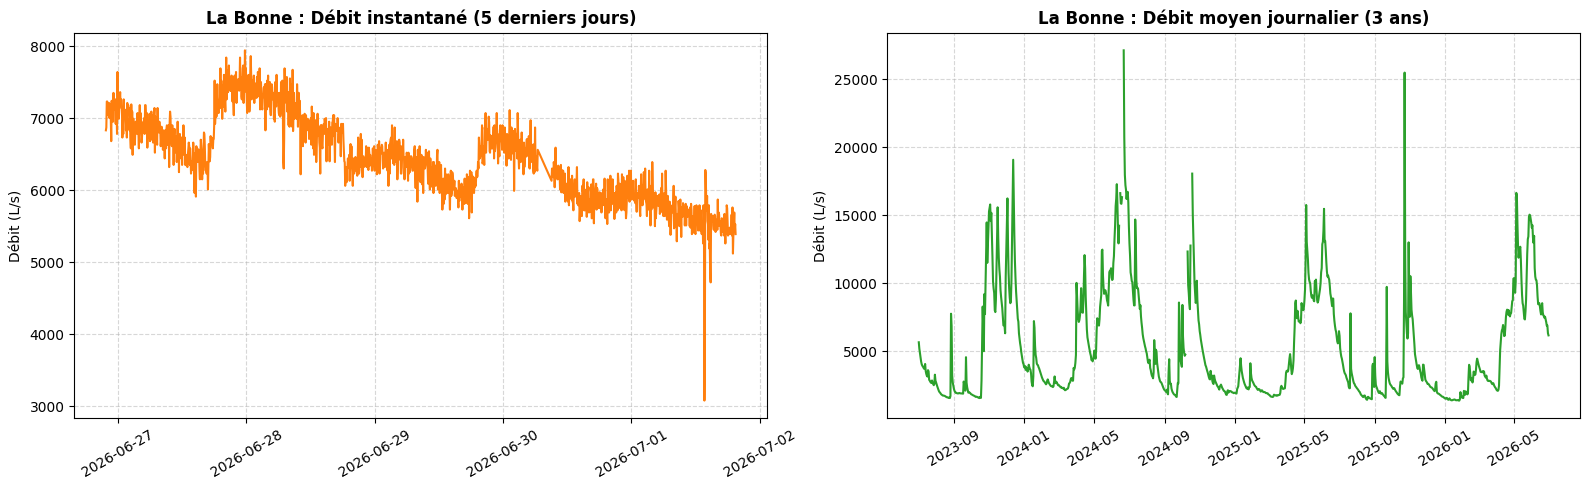

In [163]:
# Configuration
station_code = "W231401001"
now = datetime.now()

# -------------------------------------------------------------------
# 1. DÉBIT INSTANTANÉ (5 DERNIERS JOURS) - Endpoint: observations_tr
# -------------------------------------------------------------------
url_tr = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/observations_tr"
date_5j = (now - timedelta(days=5)).strftime('%Y-%m-%dT%H:%M:%SZ')

params_tr = {
    "code_entite": station_code,
    "grandeur_hydro": "Q",
    "date_fin_obs":  (now).strftime('%Y-%m-%dT%H:%M:%SZ'),
    "date_debut_obs": date_5j,
    "size": 10000,
    "sort": "asc"
}

print("Récupération des débits instantanés (5 derniers jours)...")
resp_tr = requests.get(url_tr, params=params_tr)

if resp_tr.status_code in [200, 206]:
    df_inst = pd.DataFrame(resp_tr.json()['data'])
    df_inst = df_inst[['date_obs', 'resultat_obs']].copy()
    df_inst['date_obs'] = pd.to_datetime(df_inst['date_obs'])
    df_inst['resultat_obs'] = pd.to_numeric(df_inst['resultat_obs'])
    print(f"✅ {len(df_inst)} mesures instantanées récupérées.")
else:
    print(f"❌ Erreur API TR : {resp_tr.status_code}")

# -------------------------------------------------------------------
# 2. DÉBIT MOYEN JOURNALIER QmnJ (3 DERNIÈRES ANNÉES) - Endpoint: obs_elab
# -------------------------------------------------------------------
url_elab = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
date_3ans = (now - timedelta(days=3*365)).strftime('%Y-%m-%d')

params_elab = {
    "code_entite": station_code,
    "grandeur_hydro_elab": "QmnJ", 
    "date_debut_obs_elab": date_3ans, # Paramètre corrigé pour la V2
    "size": 2000,                  
    "sort": "asc"
}

print("\nRécupération des débits moyens journaliers (3 dernières années)...")
resp_elab = requests.get(url_elab, params=params_elab)

if resp_elab.status_code in [200, 206]:
    df_moyen = pd.DataFrame(resp_elab.json()['data'])
    
    # CORRECTION : Utilisation des champs spécifiques à l'endpoint obs_elab
    df_moyen = df_moyen[['date_obs_elab', 'resultat_obs_elab']].copy()
    
    # Renommage pour uniformiser tes variables d'analyse
    df_moyen = df_moyen.rename(columns={
        'date_obs_elab': 'date_obs',
        'resultat_obs_elab': 'resultat_obs'
    })
    
    df_moyen['date_obs'] = pd.to_datetime(df_moyen['date_obs'])
    df_moyen['resultat_obs'] = pd.to_numeric(df_moyen['resultat_obs'])
    print(f"✅ {len(df_moyen)} mesures journalières récupérées.")
else:
    print(f"❌ Erreur API Élaborée : {resp_elab.status_code}")
    print(resp_elab.text)

# -------------------------------------------------------------------
# 3. VISUALISATION DES DEUX COURBES
# -------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if 'df_inst' in locals() and not df_inst.empty:
    ax1.plot(df_inst['date_obs'], df_inst['resultat_obs'], color='#ff7f0e')
    ax1.set_title("La Bonne : Débit instantané (5 derniers jours)", fontweight='bold')
    ax1.set_ylabel("Débit (L/s)")
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(True, linestyle='--', alpha=0.5)

if 'df_moyen' in locals() and not df_moyen.empty:
    ax2.plot(df_moyen['date_obs'], df_moyen['resultat_obs'], color='#2ca02c')
    ax2.set_title("La Bonne : Débit moyen journalier (3 ans)", fontweight='bold')
    ax2.set_ylabel("Débit (L/s)")
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# La météo

Récupération des données météo et neige historiques...
✅ 1096 jours de données météo récupérés.


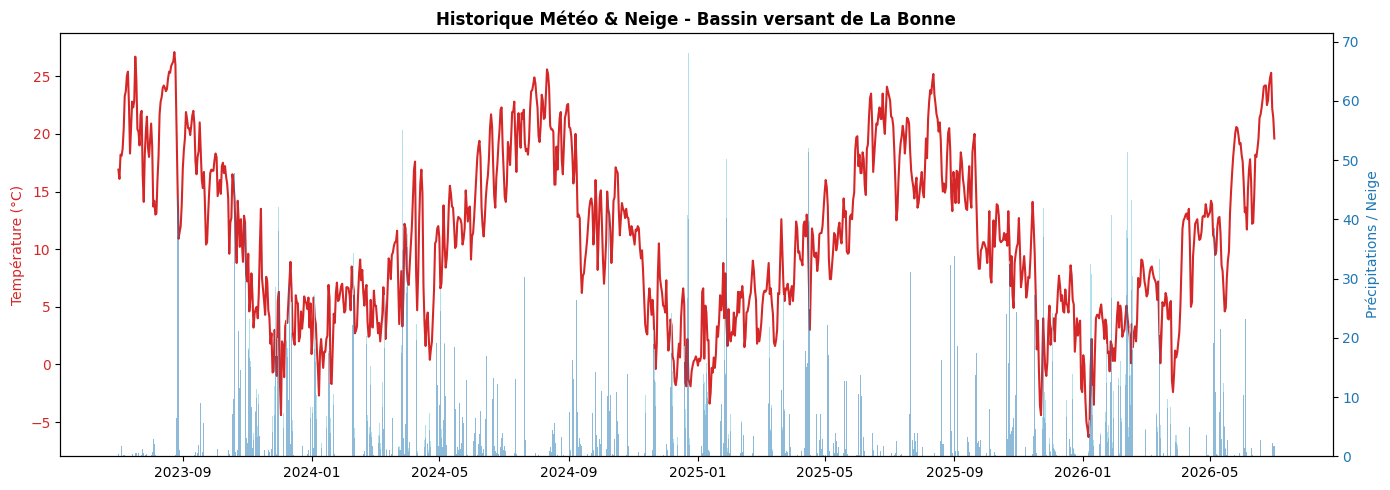

In [164]:
now = datetime.now()
date_fin = now.strftime('%Y-%m-%d')
date_debut = (now - timedelta(days=3*365)).strftime('%Y-%m-%d')

# Coordonnées géographiques de la station de La Bonne
lat, lon = 44.9003, 5.9444

# Endpoint de l'API Historique d'Open-Meteo
url_meteo = "https://archive-api.open-meteo.com/v1/archive"

params_meteo = {
    "latitude": lat,
    "longitude": lon,
    "start_date": date_debut,
    "end_date": date_fin,
    # On demande les cumuls journaliers de pluie, neige et la température moyenne
    "daily": ["temperature_2m_mean", "precipitation_sum", "snowfall_sum"],
    "timezone": "Europe/Paris"
}

print("Récupération des données météo et neige historiques...")
resp_meteo = requests.get(url_meteo, params=params_meteo)

if resp_meteo.status_code == 200:
    data_meteo = resp_meteo.json()
    
    # Extraction des données journalières
    daily_data = data_meteo['daily']
    
    # Création du DataFrame
    df_meteo = pd.DataFrame({
        'date': pd.to_datetime(daily_data['time']),
        'temperature_moyenne': daily_data['temperature_2m_mean'],
        'precipitations_cumul_mm': daily_data['precipitation_sum'],
        'chute_neige_cumul_cm': daily_data['snowfall_sum'] # Équivalent en eau/neige
    })
    
    print(f"✅ {len(df_meteo)} jours de données météo récupérés.")
    
    # Petit aperçu graphique
    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Courbe des températures
    ax1.plot(df_meteo['date'], df_meteo['temperature_moyenne'], color='#d62728', label='Température moyenne (°C)')
    ax1.set_ylabel('Température (°C)', color='#d62728')
    ax1.tick_params(axis='y', labelcolor='#d62728')

    # Axe secondaire pour les précipitations (pluie + neige)
    ax2 = ax1.twinx()
    ax2.bar(df_meteo['date'], df_meteo['precipitations_cumul_mm'], color='#1f77b4', alpha=0.5, label='Pluie (mm)')
    ax2.bar(df_meteo['date'], df_meteo['chute_neige_cumul_cm'], bottom=df_meteo['precipitations_cumul_mm'], color='#9edae5', alpha=0.8, label='Neige (cm)')
    ax2.set_ylabel('Précipitations / Neige', color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

    plt.title("Historique Météo & Neige - Bassin versant de La Bonne", fontweight='bold')
    fig.tight_layout()
    plt.show()

else:
    print(f"Erreur API Open-Meteo : {resp_meteo.status_code}")

In [544]:

# 1. Définition du bassin versant (Centre + N, S, E, O)
# Coordonnées géographiques de la station de La Bonne
lat_center, lon_center = 44.9003, 5.9444

# Distance en km pour le quadrillage
distance_km = 30

# Conversion des distances en degrés (approximation)
degree_lat = distance_km / 111  # 1 degré latitude ≈ 111 km
degree_lon = distance_km / (111 * np.cos(np.radians(lat_center)))  # 1 degré longitude ≈ 111 * cos(latitude) km

# Créer le quadrillage
lats = [lat_center - degree_lat, lat_center + degree_lat, lat_center + degree_lat, lat_center - degree_lat, lat_center - degree_lat]
lons = [lon_center - degree_lon, lon_center - degree_lon, lon_center + degree_lon, lon_center + degree_lon, lon_center - degree_lon]


# CORRECTION 1 : Open-Meteo veut une seule chaîne séparée par des virgules
lats_str = ",".join(map(str, lats))
lons_str = ",".join(map(str, lons))

url_meteo = "https://archive-api.open-meteo.com/v1/archive"

# CORRECTION 2 : On bascule tout sur 'hourly'
params_meteo = {
    "latitude": lats_str,
    "longitude": lons_str,
    "start_date": date_3ans, 
    "end_date": date_fin,    
    "hourly": ["temperature_2m", "precipitation", "snow_depth"],
    "timezone": "Europe/Paris"
}

print("Récupération de la météo horaire maillée...")
resp_meteo = requests.get(url_meteo, params=params_meteo)

if resp_meteo.status_code == 200:
    donnees_points = resp_meteo.json()
    liste_dfs = []
    
    for i, data_point in enumerate(donnees_points):
        # On crée le tableau horaire pour le point i
        df_temp = pd.DataFrame({
            'date': pd.to_datetime(data_point['hourly']['time']),
            f'temp_pt{i}': data_point['hourly']['temperature_2m'],
            f'precip_pt{i}': data_point['hourly']['precipitation'],
            f'neige_sol_pt{i}': data_point['hourly']['snow_depth'] # En mètres !
        })
        
        # CORRECTION 3 : Transformation du pas horaire au pas journalier (Resampling)
        # Moyenne pour la temp, somme pour la pluie, moyenne pour la neige au sol
        df_journalier = df_temp.set_index('date').resample('D').agg({
            f'temp_pt{i}': 'mean',
            f'precip_pt{i}': 'sum',
            f'neige_sol_pt{i}': 'mean' 
        }).reset_index()
        
        liste_dfs.append(df_journalier)
    
    # Fusion des 5 tableaux (les 5 points géographiques) sur la date
    df_bassin = reduce(lambda left, right: pd.merge(left, right, on=['date'], how='outer'), liste_dfs)
    
    # 2. CALCUL DES MOYENNES GLOBALES SUR LE BASSIN VERSANT
    cols_temp = [col for col in df_bassin.columns if 'temp_pt' in col]
    df_bassin['temperature_bassin'] = df_bassin[cols_temp].mean(axis=1)
    
    cols_precip = [col for col in df_bassin.columns if 'precip_pt' in col]
    df_bassin['precipitations_bassin'] = df_bassin[cols_precip].mean(axis=1)
    
    cols_neige = [col for col in df_bassin.columns if 'neige_sol_pt' in col]
    df_bassin['hauteur_neige_bassin'] = df_bassin[cols_neige].mean(axis=1)
    
    # Le DataFrame final, propre et prêt pour le ML
    df_meteo_clean = df_bassin[['date', 'temperature_bassin', 'precipitations_bassin', 'hauteur_neige_bassin']].copy()
    
    print(f"✅ Météo journalière moyennée sur {len(lats)} points récupérée avec succès !")
    print(df_meteo_clean.head())

else:
    print(f"❌ Erreur API : {resp_meteo.status_code}")
    print(resp_meteo.text)

Récupération de la météo horaire maillée...
✅ Météo journalière moyennée sur 5 points récupérée avec succès !
        date  temperature_bassin  precipitations_bassin  hauteur_neige_bassin
0 2023-07-02           13.690000                   0.60                   0.0
1 2023-07-03           13.533333                   0.44                   0.0
2 2023-07-04           14.061667                   0.16                   0.0
3 2023-07-05           13.506667                   2.82                   0.0
4 2023-07-06           14.221667                   0.58                   0.0


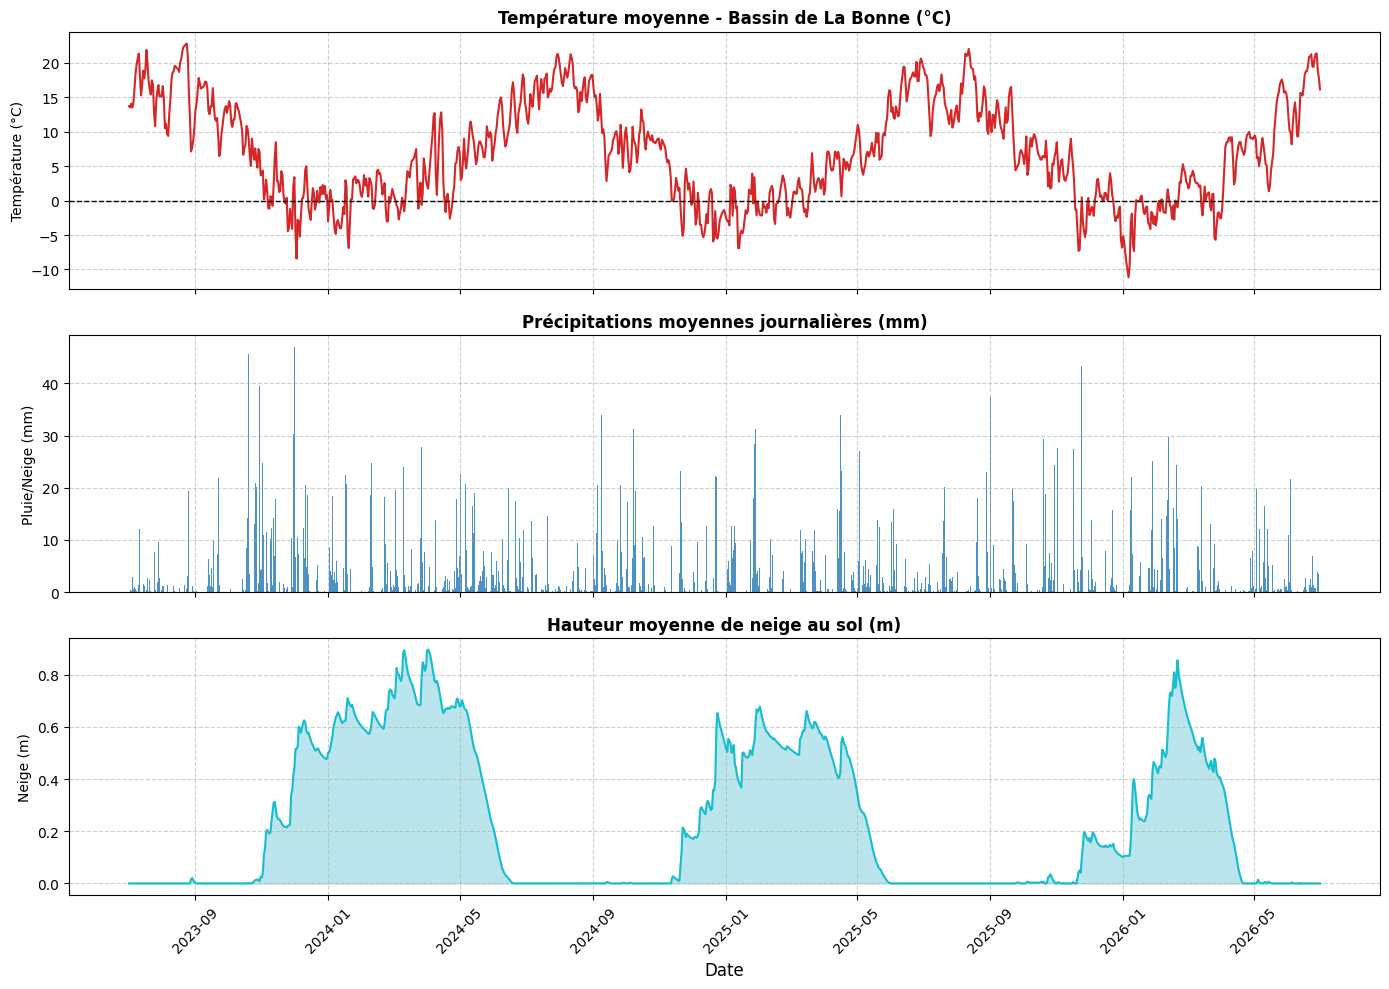

In [166]:
# Création d'une figure avec 3 sous-graphiques empilés
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# -------------------------------------------------------------------
# 1. Température (Courbe rouge)
# -------------------------------------------------------------------
ax1.plot(df_meteo_clean['date'], df_meteo_clean['temperature_bassin'], color='#d62728', linewidth=1.5)
ax1.set_title("Température moyenne - Bassin de La Bonne (°C)", fontweight='bold', fontsize=12)
ax1.set_ylabel("Température (°C)")
ax1.grid(True, linestyle='--', alpha=0.6)
# Ajout d'une ligne horizontale à 0°C pour bien voir le point de gel/fonte
ax1.axhline(0, color='black', linewidth=1, linestyle='--')

# -------------------------------------------------------------------
# 2. Précipitations (Barres bleues)
# -------------------------------------------------------------------
ax2.bar(df_meteo_clean['date'], df_meteo_clean['precipitations_bassin'], color='#1f77b4', alpha=0.8)
ax2.set_title("Précipitations moyennes journalières (mm)", fontweight='bold', fontsize=12)
ax2.set_ylabel("Pluie/Neige (mm)")
ax2.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# 3. Neige au sol (Aire remplie cyan)
# -------------------------------------------------------------------
ax3.fill_between(df_meteo_clean['date'], df_meteo_clean['hauteur_neige_bassin'], color='#9edae5', alpha=0.7)
ax3.plot(df_meteo_clean['date'], df_meteo_clean['hauteur_neige_bassin'], color='#17becf', linewidth=1.5)
ax3.set_title("Hauteur moyenne de neige au sol (m)", fontweight='bold', fontsize=12)
ax3.set_ylabel("Neige (m)")
ax3.set_xlabel("Date", fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------------
# Finitions
# -------------------------------------------------------------------
plt.xticks(rotation=45)
plt.tight_layout() # Évite que les labels ne se chevauchent
plt.show()

In [550]:
# ==========================================
# 1. FONCTIONS DE COLLECTE (Retournent des Pandas DataFrame pour la sécurité)
# ==========================================

def fetch_river_data(station_code, start_date, end_date):
    """Récupère le débit moyen journalier (QmnJ)"""
    url = "https://hubeau.eaufrance.fr/api/v2/hydrometrie/obs_elab"
    params = {
        "code_entite": station_code,
        "grandeur_hydro_elab": "QmnJ",
        "date_debut_obs_elab": pd.to_datetime(start_date).strftime('%Y-%m-%dT%H:%M:%SZ'),
        "date_fin_obs_elab": pd.to_datetime(end_date).strftime('%Y-%m-%dT%H:%M:%SZ'),
        "size": 20000,
        "sort": "asc"
    } 
    resp = requests.get(url, params=params)
    if resp.status_code in [200, 206]:
        data = resp.json().get('data', [])
        df = pd.DataFrame(data)[['date_obs_elab', 'resultat_obs_elab']]
        df = df.rename(columns={'date_obs_elab': 'date', 'resultat_obs_elab': 'debit_L_s'})
        df['date'] = pd.to_datetime(df['date'])
        return df
    else:
        raise Exception(f"Erreur Hub'Eau : {resp.status_code}")

def fetch_weather_data(lat, lon, start_date, end_date, daily_vars=["temperature_2m_max", "rain_sum"], hourly_vars=["snow_depth"]):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": daily_vars,
        "hourly": hourly_vars,
        "start_date": start_date,
        "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code != 200:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")
    data = resp.json() 
    # Traitement Quotidien
    df_daily = pd.DataFrame()
    if 'daily' in data:
        df_daily = pd.DataFrame(data['daily'])
        df_daily['date'] = pd.to_datetime(df_daily['time'])
        df_daily.drop(columns=['time'], inplace=True)
    # Traitement Horaire
    df_hourly = pd.DataFrame()
    if 'hourly' in data:
        df_hourly = pd.DataFrame(data['hourly'])
        df_hourly['date'] = pd.to_datetime(df_hourly['time'])
        df_hourly.drop(columns=['time'], inplace=True)
    return df_hourly, df_daily



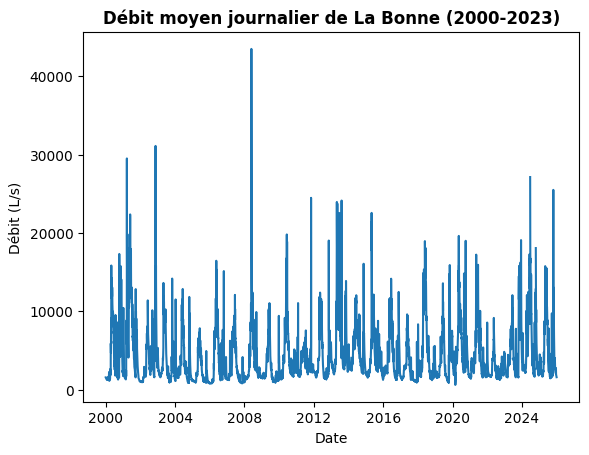

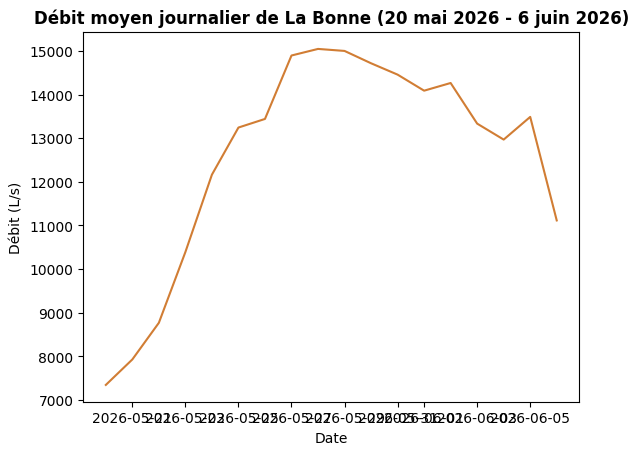

In [169]:
niveau_eau1 = fetch_river_data(station_code, datetime(2000, 1, 1), datetime(2025, 12, 31))
plt.plot(niveau_eau1['date'], niveau_eau1['debit_L_s'], color='#1f77b4')
plt.title("Débit moyen journalier de La Bonne (2000-2023)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Débit (L/s)")
plt.show()
niveau_eau2 = fetch_river_data(station_code, datetime(2026, 5, 20), datetime(2026, 6, 6))
plt.plot(niveau_eau2['date'], niveau_eau2['debit_L_s'], color="#D17D34")
plt.title("Débit moyen journalier de La Bonne (20 mai 2026 - 6 juin 2026)", fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Débit (L/s)")
plt.show()

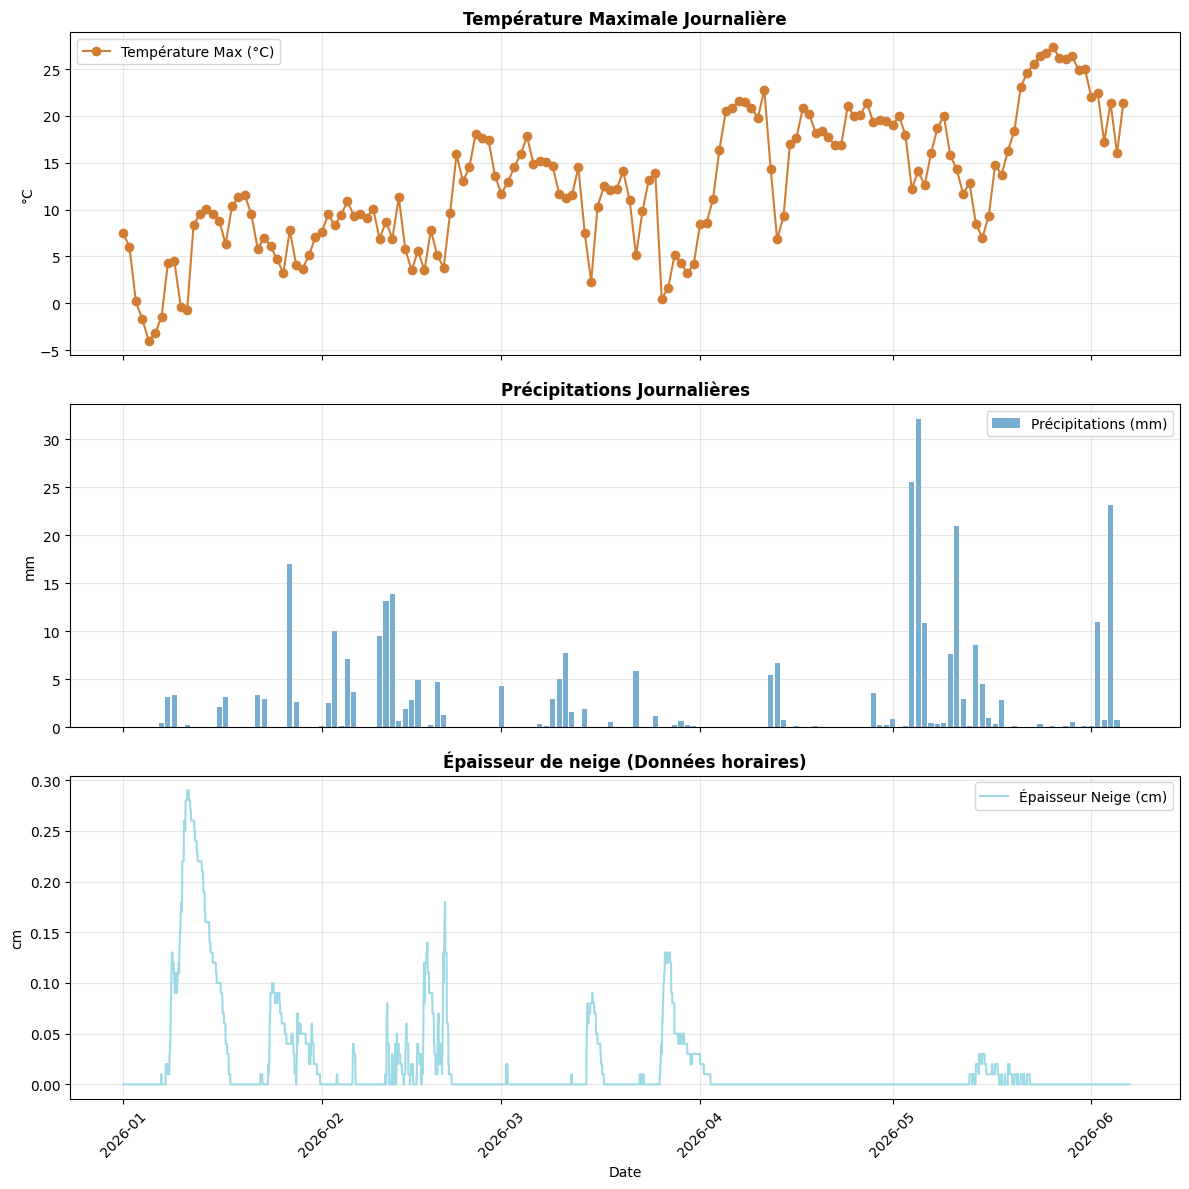

In [559]:
# 1. Appel de ta fonction (je garde tes noms de variables API)
# Utilise les noms exacts de l'API Open-Meteo : 'temperature_2m_max', 'rain_sum', 'snowfall_sum'
df_h, df_d = fetch_weather_data(
    44.9003, 5.9444, "2026-01-01", "2026-06-06", 
    daily_vars=["temperature_2m_max", "rain_sum"], 
    hourly_vars=["snow_depth"]
)



# Création d'une figure avec 3 sous-graphiques (subplots)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Graphique 1 : Température (Journalier)
ax1.plot(df_d['date'], df_d['temperature_2m_max'], color='#D17D34', marker='o', label='Température Max (°C)')
ax1.set_title("Température Maximale Journalière", fontweight='bold')
ax1.set_ylabel("°C")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Précipitations (Journalier)
ax2.bar(df_d['date'], df_d['rain_sum'], color='#1f77b4', alpha=0.6, label='Précipitations (mm)')
ax2.set_title("Précipitations Journalières", fontweight='bold')
ax2.set_ylabel("mm")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graphique 3 : Épaisseur de neige (Horaire)
ax3.plot(df_h['date'], df_h['snow_depth'], color='#9edae5', linewidth=1.5, label='Épaisseur Neige (cm)')
ax3.set_title("Épaisseur de neige (Données horaires)", fontweight='bold')
ax3.set_ylabel("cm")
ax3.set_xlabel("Date")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Mise en page
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [526]:

def fetch_temperature_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "daily": "temperature_2m_max",
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        # Extraction des données quotidiennes
        daily_temp_max = data['daily']['temperature_2m_max']
        daily_times = data['daily']['time']

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'temperature_C': daily_temp_max,
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")
    

def fetch_rain_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "daily": "rain_sum",
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        # Extraction des données quotidiennes

        daily_rain_sum = data['daily']['rain_sum']
        daily_times = data['daily']['time']

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'precip_mm': daily_rain_sum
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")
    
def fetch_snow_data(lat, lon, start_date, end_date):
    """Récupère Température, Précipitations et Neige en UN SEUL appel"""
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"
    params = {
	    "latitude": lat,
	    "longitude": lon,
	    "hourly": "snow_depth",
	    "start_date": start_date,
	    "end_date": end_date,
    }
    resp = requests.get(url, params=params)
    if resp.status_code == 200:
        data = resp.json()
        
        daily_times = data['daily']['time']

        # Extraction et conversion des données horaires en quotidiennes
        hourly_snow_depth = pd.DataFrame(data['hourly'])
        hourly_snow_depth['time'] = pd.to_datetime(hourly_snow_depth['time'])
        daily_snow_depth = hourly_snow_depth.set_index('time')['snow_depth'].resample('D').mean().reset_index()

        # Création du DataFrame final
        df = pd.DataFrame({
            'date': pd.to_datetime(daily_times),
            'snow_cm': daily_snow_depth['snow_depth']
        })
        
        return df
    else:
        raise Exception(f"Erreur Open-Meteo : {resp.status_code}")

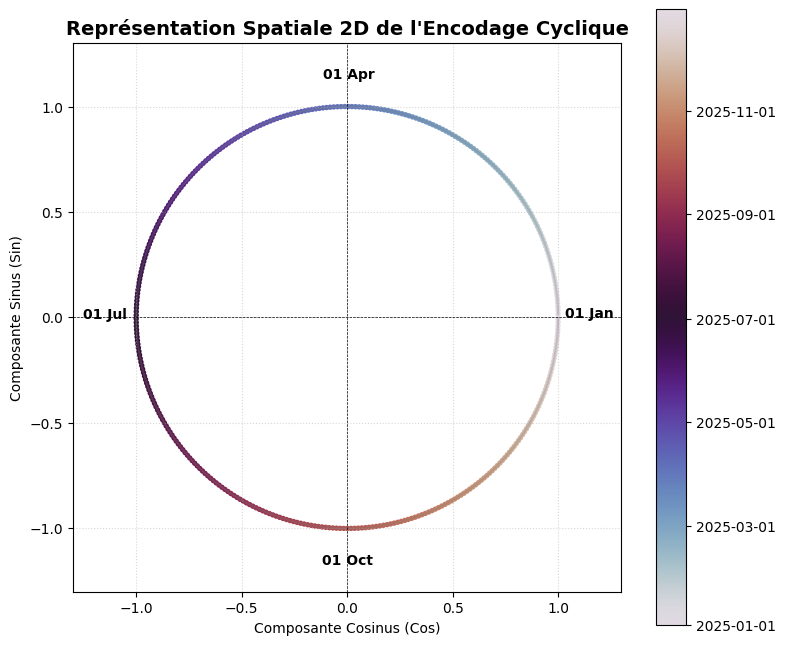

In [ ]:
def encode_cyclical_date(date_obj):
    """Encode une date en deux composantes cycliques (sin, cos) pour éviter la cassure du Nouvel An."""
    day_of_year = date_obj.dayofyear
    days_in_year = 365.25 # Prise en compte des années bissextiles
    sin_date = np.sin(2 * np.pi * day_of_year / days_in_year)
    cos_date = np.cos(2 * np.pi * day_of_year / days_in_year)
    return [sin_date, cos_date]


# 1. Génération de la plage de dates
date_range = pd.date_range(start="2025-01-01", end="2025-12-31")

# En supposant que ton encodage génère un vecteur [sin, cos]
# (Adapté ici pour correspondre aux données attendues de ta fonction encode_cyclical_date)
cyclical_features = np.array([encode_cyclical_date(date) for date in date_range])

# Extraction des composantes Sinus (Y) et Cosinus (X)
# Note : Généralement cosinus est sur l'axe X et sinus sur l'axe Y pour tourner dans le sens trigo
x_cos = cyclical_features[:, 1]  # colonne pour cos
y_sin = cyclical_features[:, 0]  # colonne pour sin

# Convertir les dates en valeurs numériques pour que Matplotlib puisse créer l'échelle de couleur
colors = mdates.date2num(date_range)

# 2. Création du graphique
fig, ax = plt.subplots(figsize=(8, 8))  # Format carré (1:1) pour avoir un cercle parfait

scatter = ax.scatter(x_cos, y_sin, c=colors, cmap='twilight', s=15, edgecolors='none')

# Relier les points par une fine ligne grise pour bien marquer la continuité du cercle
ax.plot(x_cos, y_sin, color='gray', alpha=0.3, linestyle='-')

# Ajouter des repères textuels sur le cercle pour les moments clés (Changement de saison / Trimestre)
# On prend quelques indices répartis dans l'année (ex: 1er Janvier, 1er Avril, 1er Juillet, 1er Octobre)
indices_labels = [0, 90, 181, 273] 
for idx in indices_labels:
    date_label = date_range[idx].strftime('%d %b')
    # Petit décalage (1.15) pour écrire le texte légèrement à l'extérieur du cercle unité
    ax.text(x_cos[idx] * 1.15, y_sin[idx] * 1.15, date_label, 
            fontsize=10, fontweight='bold', ha='center', va='center')

# 3. Esthétique et mise en forme autour de l'origine
ax.axhline(0, color='black', linewidth=0.5, linestyle='--') # Axe X
ax.axvline(0, color='black', linewidth=0.5, linestyle='--') # Axe Y

ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
ax.set_aspect('equal') # Force le ratio 1:1 pour éviter que le cercle ressemble à une ellipse

ax.set_title("Représentation Spatiale 2D de l'Encodage Cyclique", fontweight='bold', fontsize=14)
ax.set_xlabel("Composante Cosinus (Cos)")
ax.set_ylabel("Composante Sinus (Sin)")
ax.grid(True, linestyle=':', alpha=0.5)

# 4. Configuration de la barre de couleur (Échelle des dates)
cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', shrink=0.8)

# Formater les graduations de la colorbar pour afficher de vraies dates au lieu de nombres
# On affiche un marqueur tous les 2 mois pour ne pas surcharger
cbar.ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()
plt.show()


In [594]:
def hourly_to_wide_daily(df_hourly):
    """
    Transforme l'horaire en format large : une ligne par jour,
    avec 24 colonnes par variable (var_h0 ... var_h23). Aucune perte d'info.
    """
    if df_hourly.empty:
        return pd.DataFrame(columns=['date'])

    df_hourly = df_hourly.copy()
    df_hourly = df_hourly.sort_values('date')
    df_hourly['jour'] = df_hourly['date'].dt.floor('D')
    df_hourly['heure'] = df_hourly['date'].dt.hour

    hourly_vars = [c for c in df_hourly.columns if c not in ['date', 'jour', 'heure']]

    df_wide = df_hourly.pivot_table(index='jour', columns='heure', values=hourly_vars)
    # Aplatit le multi-index colonnes : (var, heure) -> var_h{heure}
    df_wide.columns = [f"{var}_h{heure}" for var, heure in df_wide.columns]
    df_wide = df_wide.reset_index().rename(columns={'jour': 'date'})

    # Sécurité : un jour incomplet (pas 24h) donnera des NaN sur les colonnes
    # manquantes -> il sera viré par le dropna() plus tard, ce qui est correct.
    return df_wide
def aggregate_hourly_to_daily(df_hourly, stats=('min', 'max', 'mean')):
    """
    Agrège les données horaires en indicateurs journaliers (min/max/mean par défaut)
    au lieu d'une simple moyenne, pour ne pas perdre l'info de variabilité intra-jour.
    """
    if df_hourly.empty:
        return pd.DataFrame(columns=['date'])

    df_hourly = df_hourly.copy()
    df_hourly['date'] = df_hourly['date'].dt.floor('D')  # heure -> jour

    hourly_vars = [c for c in df_hourly.columns if c != 'date']
    df_agg = df_hourly.groupby('date')[hourly_vars].agg(list(stats))

    # Aplatit le multi-index de colonnes : temperature_2m_min, temperature_2m_max, ...
    df_agg.columns = [f"{var}_{stat}" for var, stat in df_agg.columns]
    return df_agg.reset_index()

## Régression linéaire
entré : météo de 5 jours avant à 15 jours après; débit 5 jours avant, date (sin/cos), date cyclique

sortie : débit des 15 prochain jours

In [603]:
# ==========================================
# 1. PARAMÈTRES ET TÉLÉCHARGEMENT GLOBAL
# ==========================================
STATION = "W231401001"
LAT, LON = 44.913963, 6.128593

# On prend des marges aux extrémités pour pouvoir faire nos décalages (shift) 
# sans perdre le 1er janvier 2000 ou le 31 décembre 2025.
START_FETCH = "2000-01-01"
END_FETCH = "2026-06-15"

df_eau = fetch_river_data(STATION, START_FETCH, END_FETCH)

# --- ICI que tu changes ta config, tout le reste s'adapte tout seul ---
DAILY_VARS = ["rain_sum"]
HOURLY_VARS = ["temperature_2m", "snow_depth"]

df_meteo_hourly, df_meteo_daily = fetch_weather_data(
    LAT, LON, START_FETCH, END_FETCH,
    daily_vars=DAILY_VARS, hourly_vars=HOURLY_VARS
)
df_meteo_hourly_agg = aggregate_hourly_to_daily(df_meteo_hourly, stats=('mean', 'max'))

# Fusion horaire agrégé + journalier natif
df_meteo = pd.merge(df_meteo_daily, df_meteo_hourly_agg, on='date', how='outer')

df = pd.merge(df_eau, df_meteo, on='date', how='inner')

colonnes_meteo = [c for c in df_meteo.columns if c != 'date']



In [604]:
past_day = 20
predict_day = 15

# ==========================================
# 2. CONSTRUCTION DES ENTRÉES (X) ET SORTIES (Y)
# ==========================================
features_X = []
targets_Y = []

# --- A. L'historique de la rivière (J-5 à J-1) ---
for i in range(1, past_day + 1):
    nom_col = f"debit_J-{i}"
    df[nom_col] = df['debit_L_s'].shift(i)
    features_X.append(nom_col)

# --- B. La Météo passée ---
for i in range(1, past_day + 1):
    for var in colonnes_meteo:
        nom_col = f"{var}_J-{i}"
        df[nom_col] = df[var].shift(i)
        features_X.append(nom_col)

# --- C. La Météo future et actuelle (J0 à J+14) ---
# shift(-i) remonte les données futures sur la ligne actuelle
for i in range(0, max(15, predict_day + 1)):
    for var in colonnes_meteo:
        nom_col = f"{var}_J+{i}"
        df[nom_col] = df[var].shift(-i)
        features_X.append(nom_col)

# --- D. La Date cyclique ---
df['sin_date'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365.25)
df['cos_date'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365.25)
features_X.extend(['sin_date', 'cos_date'])

# --- E. La Sortie Y : Débit de la rivière de J0 à J+14 ---
for i in range(0, predict_day + 1):
    nom_col = f"cible_debit_J+{i}"
    df[nom_col] = df['debit_L_s'].shift(-i)
    targets_Y.append(nom_col)

# On supprime toutes les lignes incomplètes créées par les décalages (shift)
df = df.dropna()

# ==========================================
# 3. SÉPARATION TRAIN / TEST
# ==========================================
print("3. Séparation Entraînement / Test...")
# Entraînement strict de 2000 à fin 2020
train = df[(df['date'] >= "2000-01-01") & (df['date'] <= "2020-12-31")]
# Test sur 2021 à 2025
test = df[(df['date'] >= "2021-01-01") & (df['date'] <= "2025-12-31")]

X_train, Y_train = train[features_X], train[targets_Y]
X_test, Y_test = test[features_X], test[targets_Y]

3. Séparation Entraînement / Test...


/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/996601513.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[nom_col] = df[var].shift(i)
/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/996601513.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[nom_col] = df[var].shift(i)
/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/996601513.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

In [605]:
model_lin = LinearRegression()
model_lin.fit(X_train, Y_train)

# Prédiction sur l'année 2025
predictions = model_lin.predict(X_test)

# multioutput='raw_values' permet d'avoir le score séparé pour chaque jour du futur
scores_r2_lin = r2_score(Y_test, predictions, multioutput='raw_values')

print("\n--- RÉSULTATS DE PRÉVISION SUR 2025 ---")
for i, score in enumerate(scores_r2_lin):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")


--- RÉSULTATS DE PRÉVISION SUR 2025 ---
Prévision J0 (Aujourd'hui) : R² =  91.9 %
Prévision J+1             : R² =  86.2 %
Prévision J+2             : R² =  82.6 %
Prévision J+3             : R² =  79.5 %
Prévision J+4             : R² =  77.1 %
Prévision J+5             : R² =  74.8 %
Prévision J+6             : R² =  73.2 %
Prévision J+7             : R² =  71.3 %
Prévision J+8             : R² =  69.4 %
Prévision J+9             : R² =  67.9 %
Prévision J+10            : R² =  66.4 %
Prévision J+11            : R² =  65.1 %
Prévision J+12            : R² =  63.9 %
Prévision J+13            : R² =  62.8 %
Prévision J+14            : R² =  61.7 %
Prévision J+15            : R² =  61.1 %


In [463]:
def tracer_prediction(df_global, data_split, model, features_X, date_cible_str, titre="Graphique"):
    """
    Trace le débit avec continuité parfaite, axe X forcé pour inclure le passé,
    et axe Y plafonné intelligemment.
    """
    date_cible = pd.to_datetime(date_cible_str)
    
    # 1. Vérification de la présence de la date
    ligne_J0 = data_split[data_split['date'] == date_cible]
    if ligne_J0.empty:
        print(f"❌ La date '{date_cible_str}' n'est pas disponible dans ce bloc ({titre}).")
        return
        
    # Re-génération locale des noms de colonnes cibles (Y)
    targets_Y = [f"cible_debit_J+{i}" for i in range(predict_day + 1)]
        
    # 2. Récupération du passé (15 jours avant J0, inclus)
    contexte = df_global[(df_global['date'] >= date_cible - pd.Timedelta(days=15)) & 
                         (df_global['date'] <= date_cible)]
    
    # 3. Prédictions
    X_input = ligne_J0[features_X]
    Y_vrai_futur = ligne_J0[targets_Y].values[0]
    Y_pred_futur = model.predict(X_input)[0]
    
    # 4. Raccordement au point J0 pour continuité visuelle
    debit_actuel = ligne_J0['debit_L_s'].values[0]
    dates_futures = [date_cible] + list(pd.date_range(start=date_cible + pd.Timedelta(days=1), periods=predict_day+1))
    Y_vrai_continu = [debit_actuel] + list(Y_vrai_futur)
    Y_pred_continu = [debit_actuel] + list(Y_pred_futur)
    
    # --- NOUVEAU : Calcul de la limite de l'axe Y ---
    # On prend le max absolu de tout ce qu'on affiche
    max_affiche = max(
        contexte['debit_L_s'].max() if not contexte.empty else 0,
        max(Y_vrai_continu),
        max(Y_pred_continu)
    )
    # On ajoute +10% de marge en haut pour aérer, sans jamais dépasser 12000
    limite_y = max(12000, max_affiche * 1.1)

    # ==========================================
    # 5. VISUALISATION ÉPURÉE
    # ==========================================
    plt.figure(figsize=(12, 6))
    
    # Tracés
    plt.plot(contexte['date'], contexte['debit_L_s'], color='black', linewidth=2.5, label="Passé (Hub'Eau)")
    plt.plot(dates_futures, Y_vrai_continu, color='blue', marker='o', linestyle=':', linewidth=2, label="Vrai Futur (Réalité)")
    plt.plot(dates_futures, Y_pred_continu, color='red', marker='X', linestyle='-', linewidth=2, label="Prédiction")
    
    # Formatage strict
    plt.axvline(date_cible, color='grey', linestyle='--', alpha=0.7)
    
    # --- NOUVEAU : Forcer explicitement le cadre ---
    plt.xlim(left=date_cible - pd.Timedelta(days=15), right=dates_futures[-1])
    plt.ylim(bottom=0, top=limite_y)
    
    # Inclinaison des dates pour éviter qu'elles ne se superposent
    plt.xticks(rotation=45, ha='right')
    
    plt.title(f"{titre} (Départ : {date_cible.strftime('%Y-%m-%d')})", fontweight='bold', fontsize=14)
    plt.ylabel("Débit (L/s)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


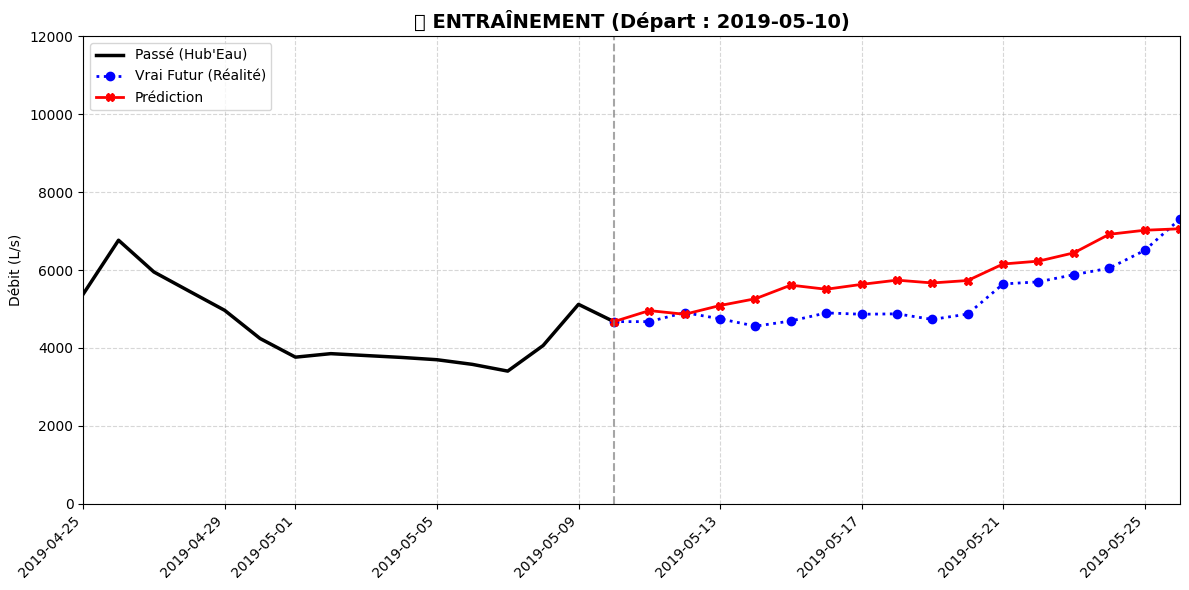

/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


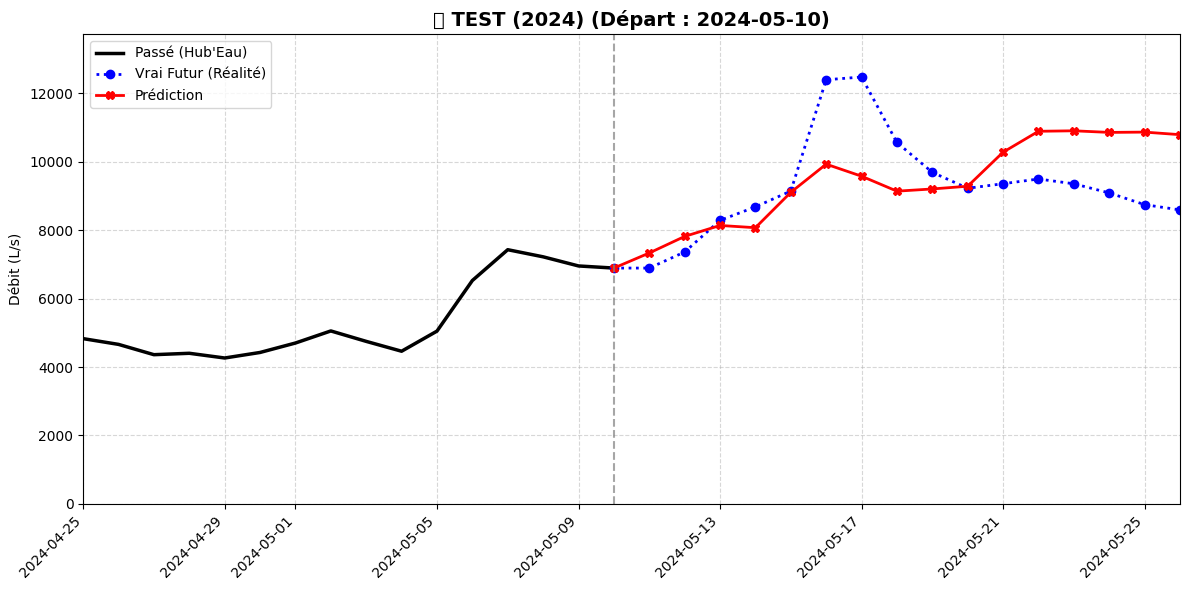

In [610]:
# ==========================================
# APPELS DES TRACÉS
# ==========================================
tracer_prediction(df, train, model_lin, features_X, "2019-05-10", "🟢 ENTRAÎNEMENT")
tracer_prediction(df, test, model_lin, features_X, "2024-05-10", "🔴 TEST (2024)")

In [331]:
# 1. Dates dynamiques
aujourdhui = pd.Timestamp.now().normalize()
start_live = (aujourdhui - timedelta(days=25)).strftime('%Y-%m-%d')
end_live = (aujourdhui + timedelta(days=15)).strftime('%Y-%m-%d')

# 2. Téléchargement et Fusion
df_eau_live = fetch_river_data(STATION, start_live, aujourdhui.strftime('%Y-%m-%d'))
df_meteo_live = fetch_weather_data(LAT, LON, start_live, end_live)
df = pd.merge(df_meteo_live, df_eau_live, on='date', how='left')

# 3. Construction brute des variables (l'ordre n'a plus d'importance ici)
for i in range(1, 6):
    df[f"debit_J-{i}"] = df['debit_L_s'].shift(i)
    for var in ['temperature_C', 'precip_mm', 'snow_cm']:
        df[f"{var}_J-{i}"] = df[var].shift(i)

for i in range(15):
    for var in ['temperature_C', 'precip_mm', 'snow_cm']:
        df[f"{var}_J+{i}"] = df[var].shift(-i)

df['sin_date'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365.25)
df['cos_date'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365.25)

# 4. Extraction de J0 avec l'ordre strict imposé par le modèle
# model.feature_names_in_ contient l'ordre parfait de l'entraînement
features_ordonnees = model_lin.feature_names_in_



ligne_J0 = df.iloc[-1:]
date_J0 = ligne_J0['date'].iloc[0]

# Inférence : Le modèle est content, l'ordre est parfait
X_live = ligne_J0[features_ordonnees]
Y_pred_live = model_lin.predict(X_live)[0]

# 5. Visualisation avec Raccordement Parfait
date_J_moins_1 = date_J0 - pd.Timedelta(days=1)

# Contexte (Noir) jusqu'à J-1 inclus
contexte = df[(df['date'] >= date_J0 - pd.Timedelta(days=15)) & (df['date'] <= date_J_moins_1)]

# Préparation de la courbe rouge pour la continuité
vrai_debit_J_moins_1 = ligne_J0['debit_J-1'].iloc[0]

# On ajoute la date et la valeur de J-1 au tout début des prédictions (J0 à J+14)
dates_rouges = [date_J_moins_1] + list(pd.date_range(start=date_J0, periods=15))
valeurs_rouges = [vrai_debit_J_moins_1] + list(Y_pred_live)

# Tracés
plt.figure(figsize=(12, 6))
plt.plot(contexte['date'], contexte['debit_L_s'], color='black', linewidth=2.5, label="Passé (Hub'Eau)")
plt.plot(dates_rouges, valeurs_rouges, color='red', marker='X', linestyle='-', linewidth=2, label="Prédiction")

# Formatage strict
plt.axvline(date_J0, color='grey', linestyle='--')
plt.ylim(bottom=0)
plt.title(f"Prévision en direct (Départ : {date_J0.strftime('%Y-%m-%d')})", fontweight='bold')
plt.ylabel("Débit (L/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: "['debit_J-6', 'debit_J-7', 'debit_J-8', 'debit_J-9', 'debit_J-10', 'debit_J-11', 'debit_J-12', 'debit_J-13', 'debit_J-14', 'debit_J-15', 'debit_J-16', 'debit_J-17', 'debit_J-18', 'debit_J-19', 'debit_J-20', 'temperature_C_J-6', 'precip_mm_J-6', 'snow_cm_J-6', 'temperature_C_J-7', 'precip_mm_J-7', 'snow_cm_J-7', 'temperature_C_J-8', 'precip_mm_J-8', 'snow_cm_J-8', 'temperature_C_J-9', 'precip_mm_J-9', 'snow_cm_J-9', 'temperature_C_J-10', 'precip_mm_J-10', 'snow_cm_J-10', 'temperature_C_J-11', 'precip_mm_J-11', 'snow_cm_J-11', 'temperature_C_J-12', 'precip_mm_J-12', 'snow_cm_J-12', 'temperature_C_J-13', 'precip_mm_J-13', 'snow_cm_J-13', 'temperature_C_J-14', 'precip_mm_J-14', 'snow_cm_J-14', 'temperature_C_J-15', 'precip_mm_J-15', 'snow_cm_J-15', 'temperature_C_J-16', 'precip_mm_J-16', 'snow_cm_J-16', 'temperature_C_J-17', 'precip_mm_J-17', 'snow_cm_J-17', 'temperature_C_J-18', 'precip_mm_J-18', 'snow_cm_J-18', 'temperature_C_J-19', 'precip_mm_J-19', 'snow_cm_J-19', 'temperatu


--- DÉBIT DE BASE ESTIMÉ (Biais B par jour) ---
Biais pour J+0 : -86.06 L/s
Biais pour J+1 : -174.76 L/s
Biais pour J+2 : -239.59 L/s
Biais pour J+3 : -287.93 L/s
Biais pour J+4 : -319.82 L/s
Biais pour J+5 : -314.53 L/s
Biais pour J+6 : -265.27 L/s
Biais pour J+7 : -184.67 L/s
Biais pour J+8 : -147.98 L/s
Biais pour J+9 : -105.82 L/s
Biais pour J+10 : -75.60 L/s
Biais pour J+11 : -51.01 L/s
Biais pour J+12 : -2.56 L/s
Biais pour J+13 : 78.99 L/s
Biais pour J+14 : 194.44 L/s
Biais pour J+15 : 316.03 L/s


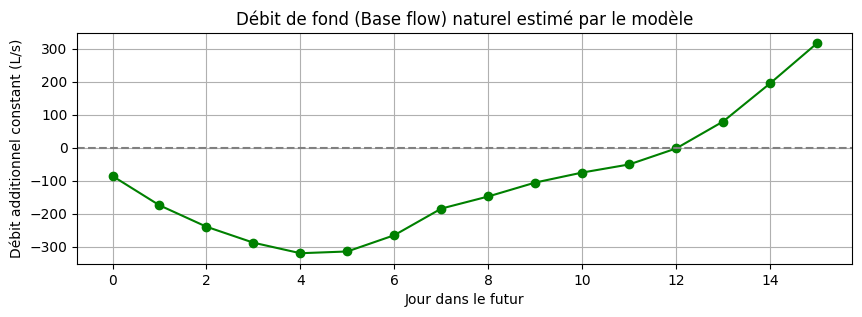

In [609]:
# --- Extraction du vecteur de constante B ---
# model.intercept_ contient le vecteur de biais pour tes 15 jours de sortie
biais_vecteur = model_lin.intercept_

# Affichage pour les 15 jours
print("\n--- DÉBIT DE BASE ESTIMÉ (Biais B par jour) ---")
for i, b in enumerate(biais_vecteur):
    print(f"Biais pour J+{i} : {b:.2f} L/s")

# --- Visualisation rapide du vecteur ---
plt.figure(figsize=(10, 3))
plt.plot(range(predict_day + 1), biais_vecteur, marker='o', color='green', label="Apport souterrain estimé")
plt.axhline(0, color='grey', linestyle='--')
plt.title("Débit de fond (Base flow) naturel estimé par le modèle")
plt.xlabel("Jour dans le futur")
plt.ylabel("Débit additionnel constant (L/s)")
plt.grid(True)
plt.show()

## Polynomiale

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

In [464]:
model_pl = make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=100))
model_pl.fit(X_train, Y_train)

# Prédiction sur l'année 2025
predictions = model_pl.predict(X_test)

# multioutput='raw_values' permet d'avoir le score séparé pour chaque jour du futur
scores_r2_pl = r2_score(Y_test, predictions, multioutput='raw_values')

print("\n--- RÉSULTATS DE PRÉVISION SUR 2025 ---")
for i, score in enumerate(scores_r2_pl):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<predict_day} : R² = {score * 100:>5.1f} %")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(



--- RÉSULTATS DE PRÉVISION SUR 2025 ---


ValueError: Invalid format specifier '<predict_day' for object of type 'str'

In [461]:
tracer_prediction(df, train, model_pl, features_X, "2019-05-10", "🟢 ENTRAÎNEMENT")
tracer_prediction(df, test, model_pl, features_X, "2024-05-10", "🔴 TEST (2024)")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- precip_mm_J+16
- precip_mm_J+17
- precip_mm_J+18
- precip_mm_J+19
- precip_mm_J+20
- ...


## Random Forest

In [607]:
# Instanciation et entraînement
model_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

# Prédiction sur l'année de test
predictions_rf = model_rf.predict(X_test)

# Évaluation jour par jour
scores_r2_rf = r2_score(Y_test, predictions_rf, multioutput='raw_values')

print("\n--- RÉSULTATS FORÊT ALÉATOIRE (Random Forest) ---")
for i, score in enumerate(scores_r2_rf):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")


--- RÉSULTATS FORÊT ALÉATOIRE (Random Forest) ---
Prévision J0 (Aujourd'hui) : R² =  90.5 %
Prévision J+1             : R² =  85.2 %
Prévision J+2             : R² =  81.6 %
Prévision J+3             : R² =  78.7 %
Prévision J+4             : R² =  75.5 %
Prévision J+5             : R² =  74.5 %
Prévision J+6             : R² =  73.7 %
Prévision J+7             : R² =  73.1 %
Prévision J+8             : R² =  72.6 %
Prévision J+9             : R² =  71.5 %
Prévision J+10            : R² =  69.9 %
Prévision J+11            : R² =  68.8 %
Prévision J+12            : R² =  67.7 %
Prévision J+13            : R² =  66.5 %
Prévision J+14            : R² =  65.7 %
Prévision J+15            : R² =  64.1 %


/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


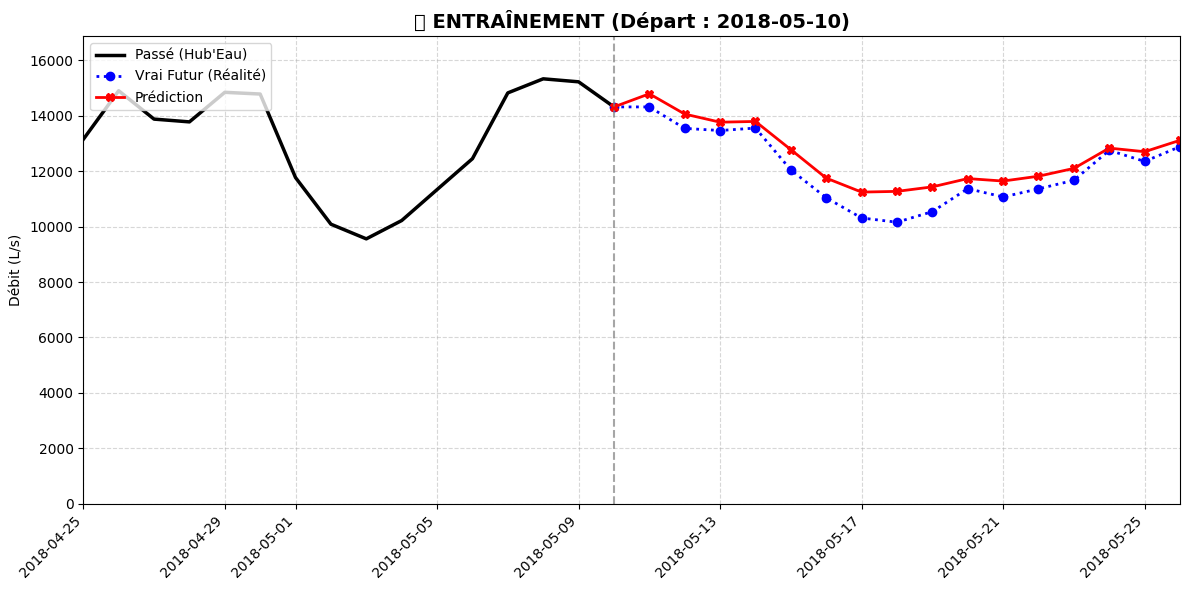

/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_49215/1263000521.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


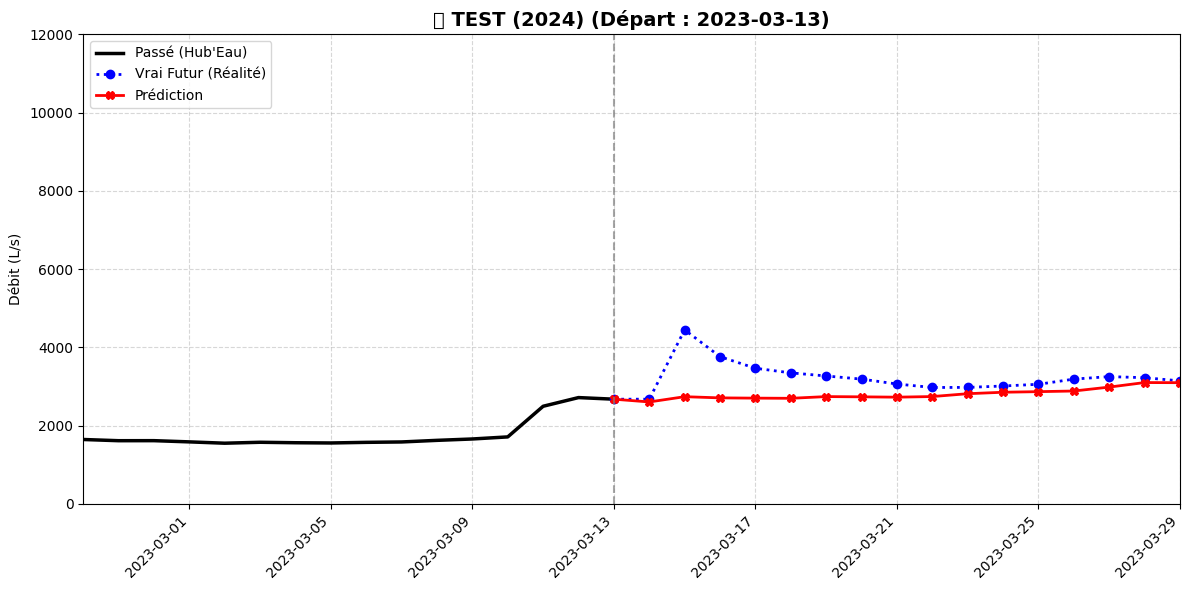

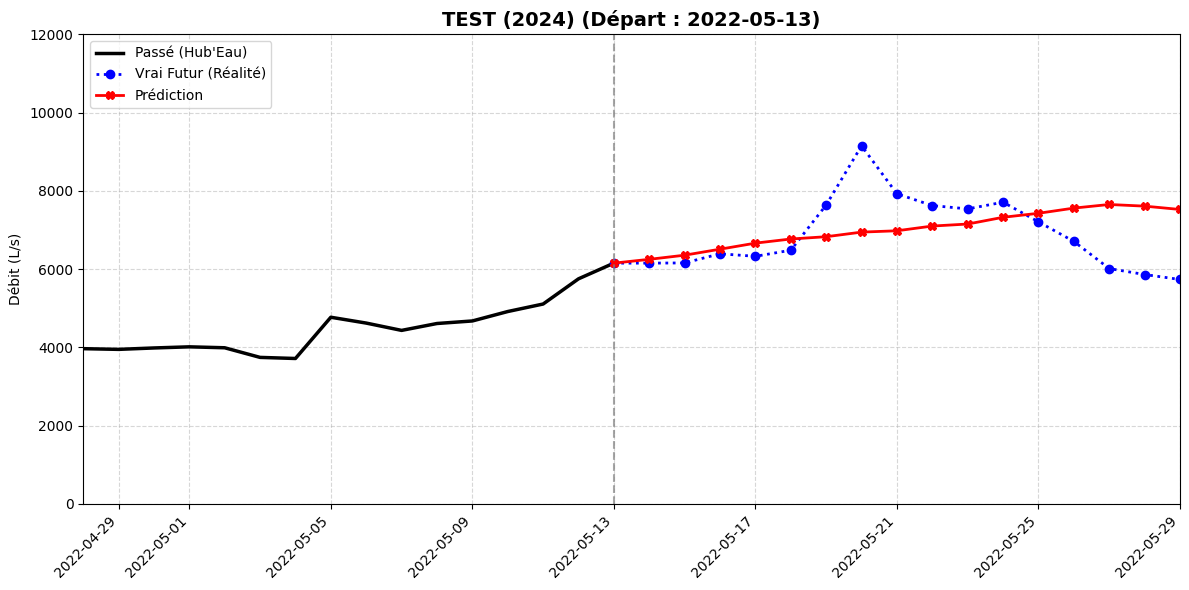

In [608]:
tracer_prediction(df, train, model_rf, features_X, "2018-05-10", "🟢 ENTRAÎNEMENT")
tracer_prediction(df, test, model_rf, features_X, "2023-03-13", "🔴 TEST (2024)")
tracer_prediction(df, test, model_rf, features_X, "2022-05-13", "TEST (2024)")

## BOOSTING

In [611]:
# Instanciation du modèle de base, enveloppé pour supporter les 15 dimensions de Y
modele_de_base_gb = HistGradientBoostingRegressor(random_state=42, l2_regularization=0.1)
model_gb = MultiOutputRegressor(modele_de_base_gb)

# Entraînement
model_gb.fit(X_train, Y_train)

# Prédiction sur l'année de test
predictions_gb = model_gb.predict(X_test)

# Évaluation jour par jour
scores_r2_gb = r2_score(Y_test, predictions_gb, multioutput='raw_values')

print("\n--- RÉSULTATS GRADIENT BOOSTING ---")
for i, score in enumerate(scores_r2_gb):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")


--- RÉSULTATS GRADIENT BOOSTING ---
Prévision J0 (Aujourd'hui) : R² =  92.6 %
Prévision J+1             : R² =  88.4 %
Prévision J+2             : R² =  85.5 %
Prévision J+3             : R² =  81.8 %
Prévision J+4             : R² =  80.1 %
Prévision J+5             : R² =  77.3 %
Prévision J+6             : R² =  77.1 %
Prévision J+7             : R² =  74.9 %
Prévision J+8             : R² =  73.3 %
Prévision J+9             : R² =  72.5 %
Prévision J+10            : R² =  70.9 %
Prévision J+11            : R² =  71.5 %
Prévision J+12            : R² =  70.6 %
Prévision J+13            : R² =  70.1 %
Prévision J+14            : R² =  70.2 %
Prévision J+15            : R² =  68.1 %


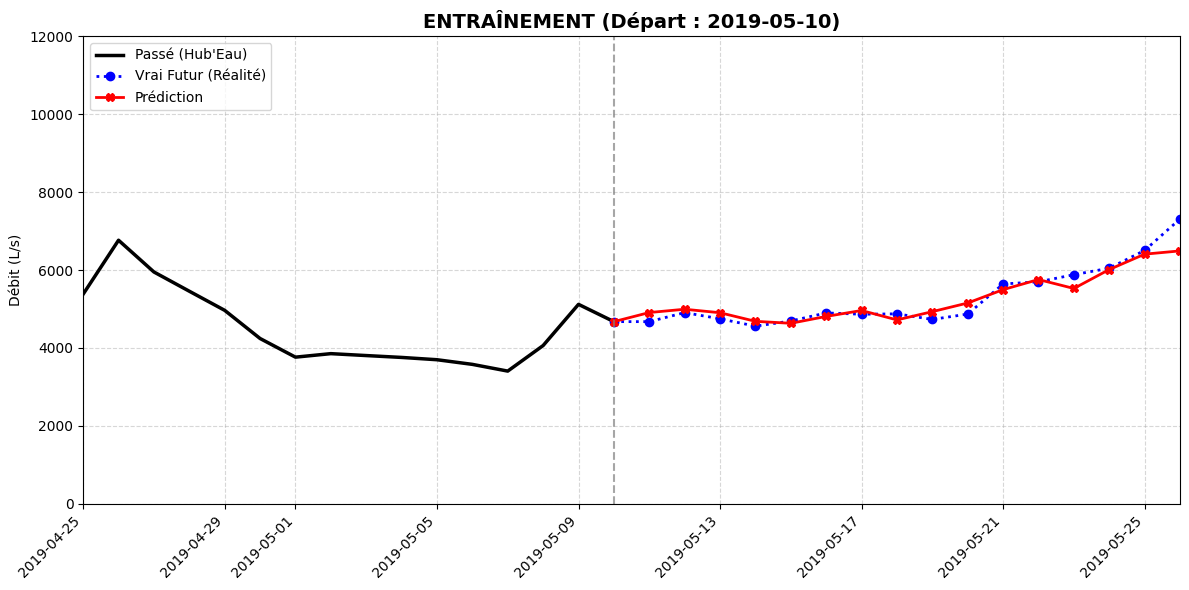

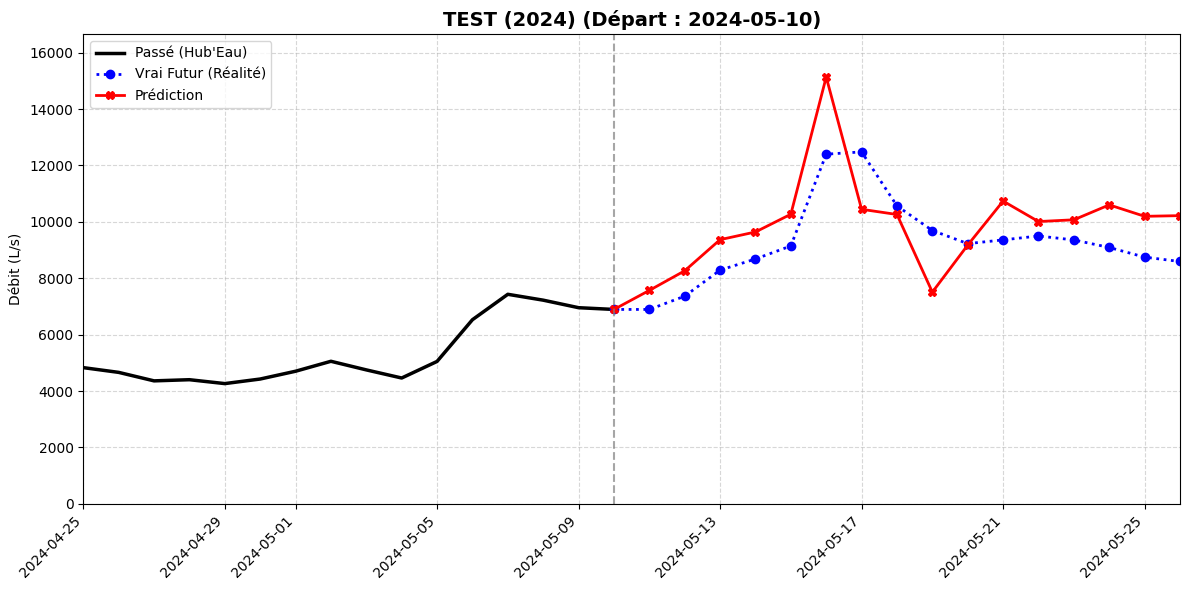

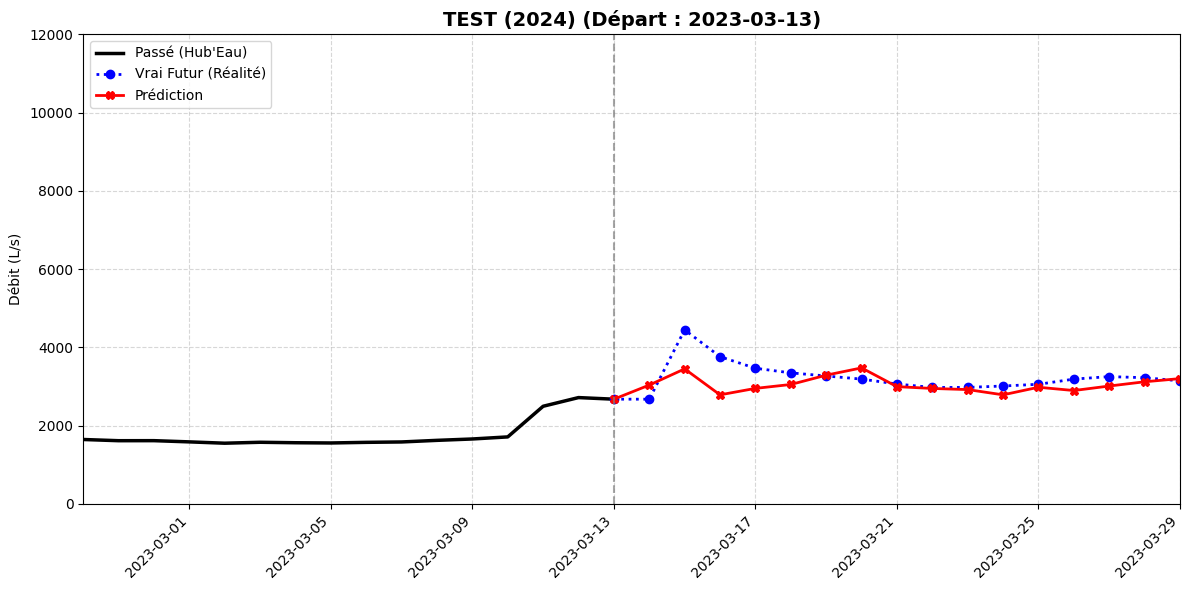

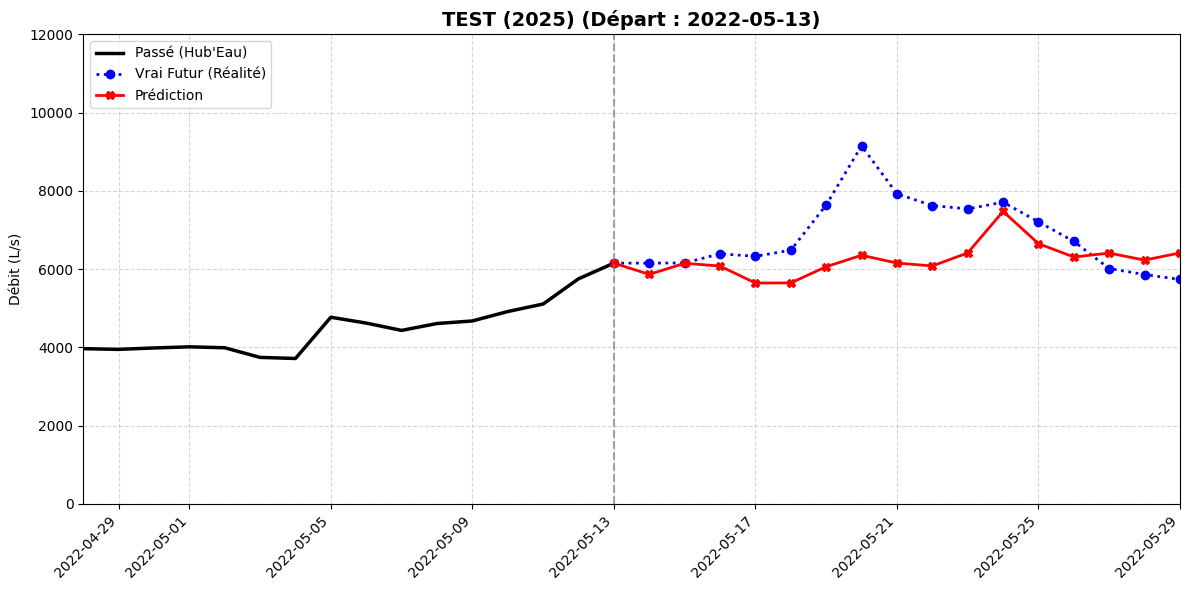

In [612]:
tracer_prediction(df, train, model_gb, features_X, "2019-05-10", "ENTRAÎNEMENT")
tracer_prediction(df, test, model_gb, features_X, "2024-05-10", "TEST (2024)")
tracer_prediction(df, test, model_gb, features_X, "2023-03-13", "TEST (2024)")
tracer_prediction(df, test, model_gb, features_X, "2022-05-13", "TEST (2025)")

In [613]:
# Un réseau avec 2 couches cachées de 100 et 50 neurones

model_nn = MLPRegressor(
    # 1. L'ARCHITECTURE : (128, 64) signifie une 1ère couche de 128 neurones, puis 64. 
    # Tu peux tester plus profond : (128, 64, 32) ou plus large : (200, 100)
    hidden_layer_sizes=(64, 32), 
    

    
    # 3. LA TAILLE DU LOT (Batch Size) : Le nombre de lignes lues avant de mettre à jour le modèle.
    # Scikit-Learn met 200 par défaut. Essaie 32 ou 64 pour aider le modèle à généraliser.
    batch_size=64,
    
    # 4. LA RÉGULARISATION (Alpha) : C'est l'équivalent du "Dropout". 
    # Ça pénalise les poids trop gros pour empêcher le modèle d'apprendre par cœur (overfitting).
    alpha=100,
    
    activation='relu',
    solver='adam',
    random_state=42
)
# Entraînement
model_nn.fit(X_train, Y_train)

# Prédiction sur l'année de test
predictions_nn = model_nn.predict(X_test)

# Évaluation jour par jour
scores_r2_nn = r2_score(Y_test, predictions_nn, multioutput='raw_values')

print("\n--- RÉSULTATS RESEAUX DE NEURONES ---")
for i, score in enumerate(scores_r2_nn):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")




--- RÉSULTATS RESEAUX DE NEURONES ---
Prévision J0 (Aujourd'hui) : R² =  91.7 %
Prévision J+1             : R² =  85.9 %
Prévision J+2             : R² =  82.1 %
Prévision J+3             : R² =  79.4 %
Prévision J+4             : R² =  76.5 %
Prévision J+5             : R² =  73.6 %
Prévision J+6             : R² =  70.7 %
Prévision J+7             : R² =  68.2 %
Prévision J+8             : R² =  66.1 %
Prévision J+9             : R² =  63.1 %
Prévision J+10            : R² =  60.8 %
Prévision J+11            : R² =  59.6 %
Prévision J+12            : R² =  58.3 %
Prévision J+13            : R² =  55.3 %
Prévision J+14            : R² =  53.4 %
Prévision J+15            : R² =  51.7 %


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


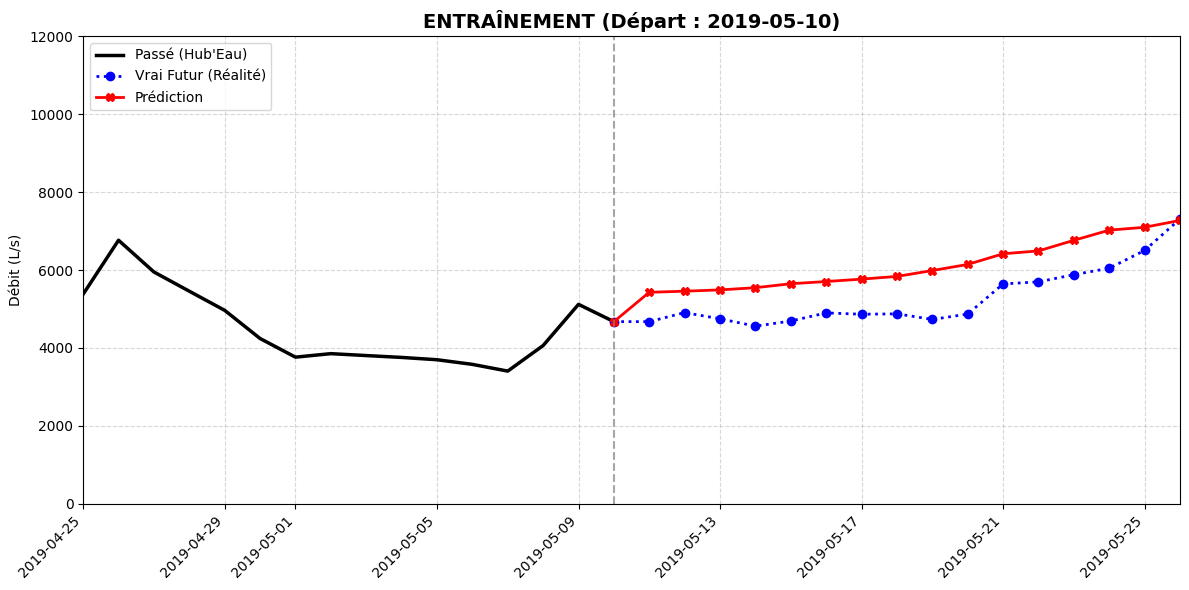

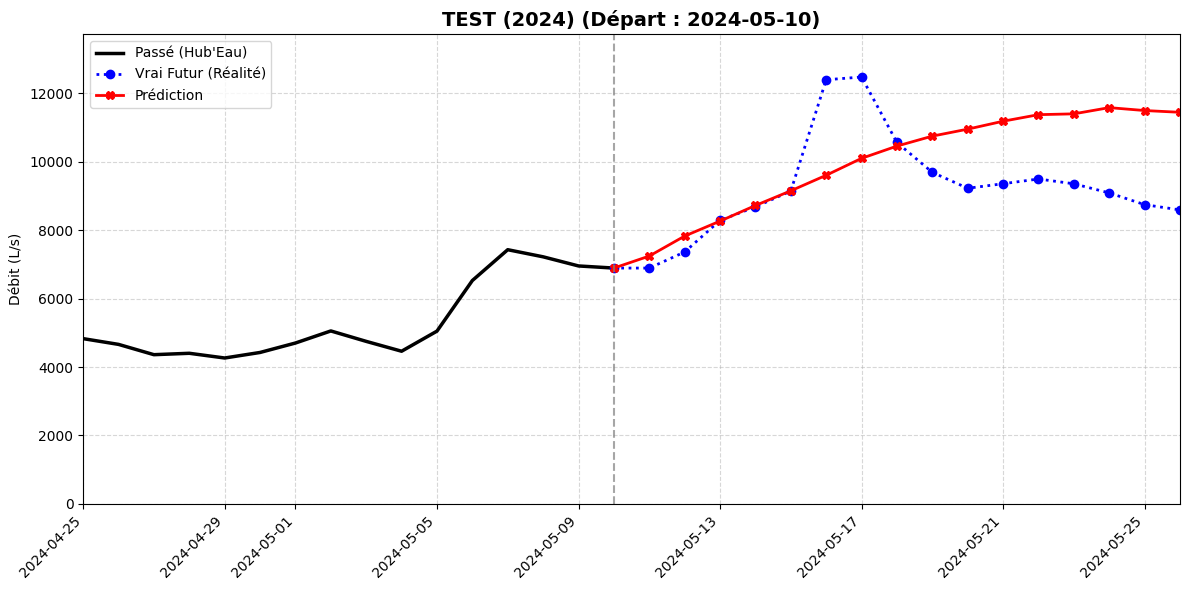

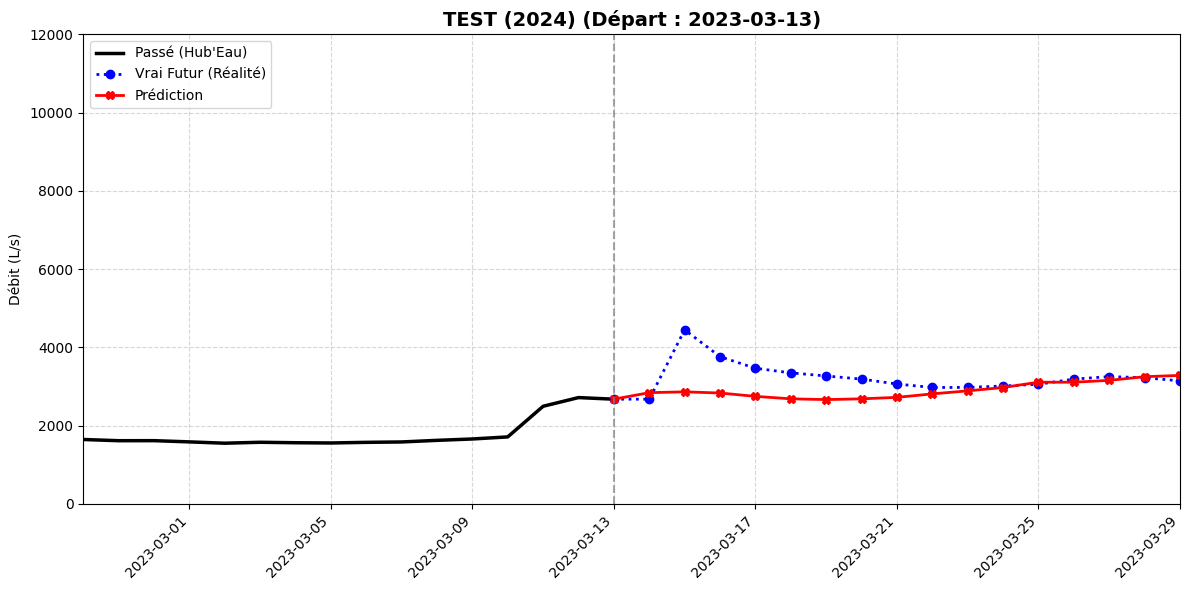

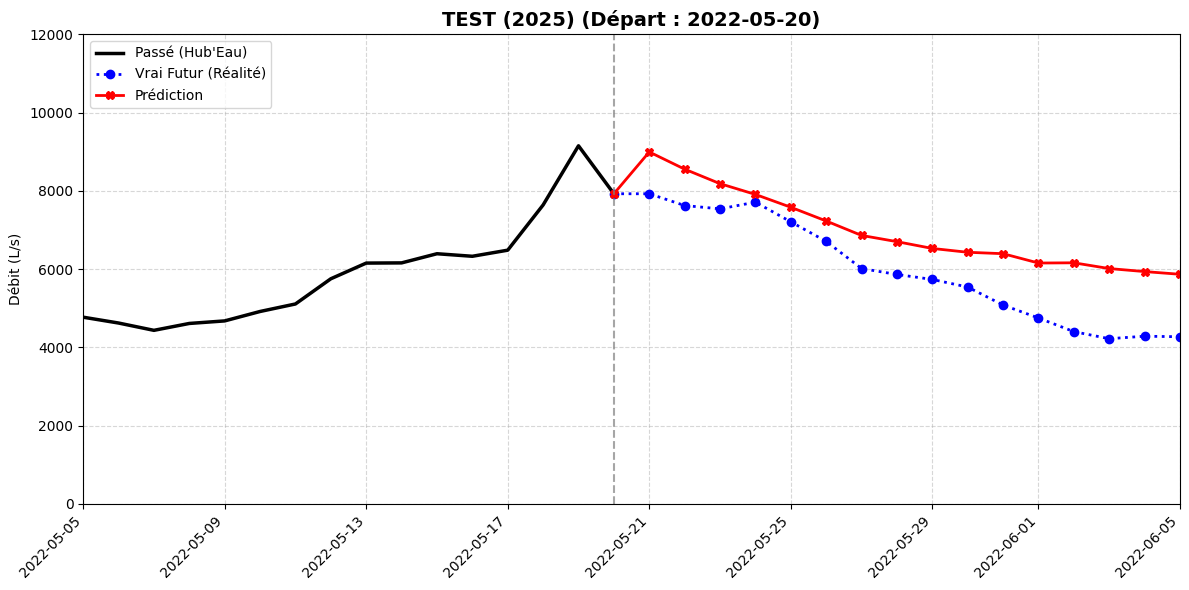

In [469]:
tracer_prediction(df, train, model_nn, features_X, "2019-05-10", "ENTRAÎNEMENT")
tracer_prediction(df, test, model_nn, features_X, "2024-05-10", "TEST (2024)")
tracer_prediction(df, test, model_nn, features_X, "2023-03-13", "TEST (2024)")
tracer_prediction(df, test, model_nn, features_X, "2022-05-20", "TEST (2025)")

In [614]:

# Fixer la graine pour la reproductibilité
tf.random.set_seed(42)

# --- LE FIX EST ICI : Conversion des DataFrames Pandas en matrices NumPy ---
X_train_np = X_train[features_X].values.astype(np.float32)
Y_train_np = Y_train[targets_Y].values.astype(np.float32)
X_test_np = X_test[features_X].values.astype(np.float32)
Y_test_np = Y_test[targets_Y].values.astype(np.float32)

# 1. Couche de normalisation intégrée
norm_layer = tf.keras.layers.Normalization(input_shape=(X_train_np.shape[1],))

# 2. Construction du modèle
model_keras = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(150, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(predict_day + 1) # Sortie pour tes 15 jours
])

# 3. Compilation
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_keras.compile(loss="mse", optimizer=optimizer)

# 4. Entraînement de la couche de normalisation sur les données brutes
norm_layer.adapt(X_train_np)

# 5. Entraînement du réseau
print("Début de l'entraînement Keras...")
history = model_keras.fit(X_train_np, Y_train_np, epochs=50, validation_split=0.1, verbose=1)

# 6. Évaluation
print("\nCalcul des prédictions sur le jeu de test...")
predictions_keras = model_keras.predict(X_test_np)

scores_r2_keras = r2_score(Y_test_np, predictions_keras, multioutput='raw_values')

print("\n--- RÉSULTATS TENSORFLOW / KERAS ---")
for i, score in enumerate(scores_r2_keras):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")

Début de l'entraînement Keras...
Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13532300.0000 - val_loss: 5157318.5000
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - loss: 4237994.0000 - val_loss: 3991184.7500
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 3625603.2500 - val_loss: 3522147.0000
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - loss: 3353094.2500 - val_loss: 3306706.2500
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 3192028.7500 - val_loss: 3166546.7500
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - loss: 3059163.7500 - val_loss: 3036144.2500
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 2933108.7500 - val_loss: 2909936.5000
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - loss: 2811233.0000 - val_loss: 2795821.2500
Epoch 9/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 2700903.5000 - val_loss: 2683170.0000
Epoch 10/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - loss: 2595435.2500 - val_loss: 2579187.7500
Epoch 11/50

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


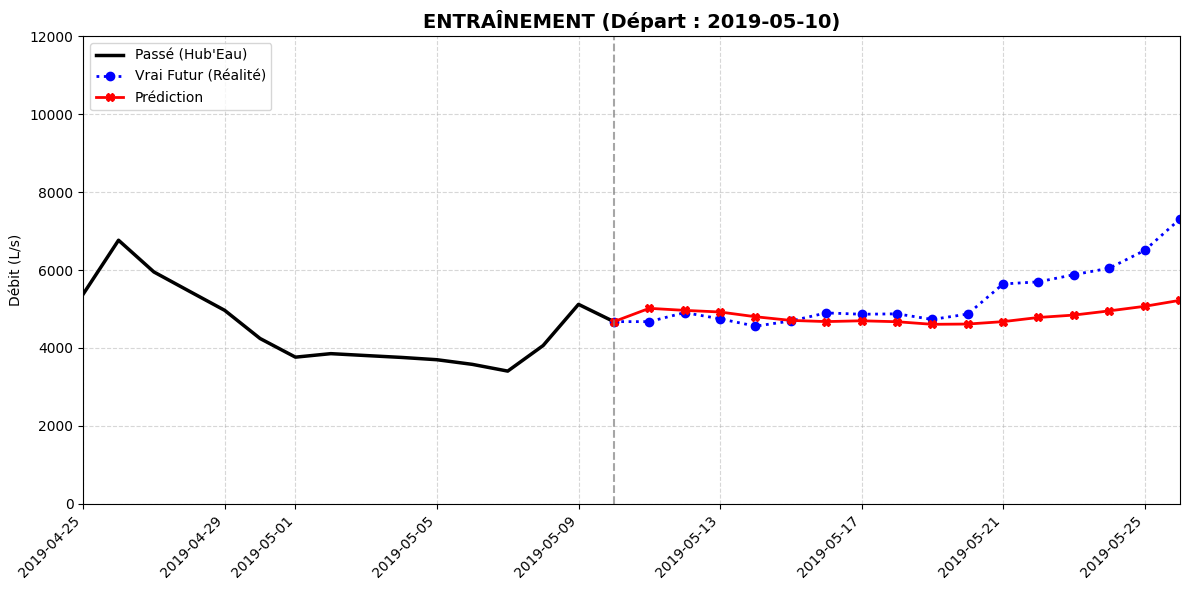

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


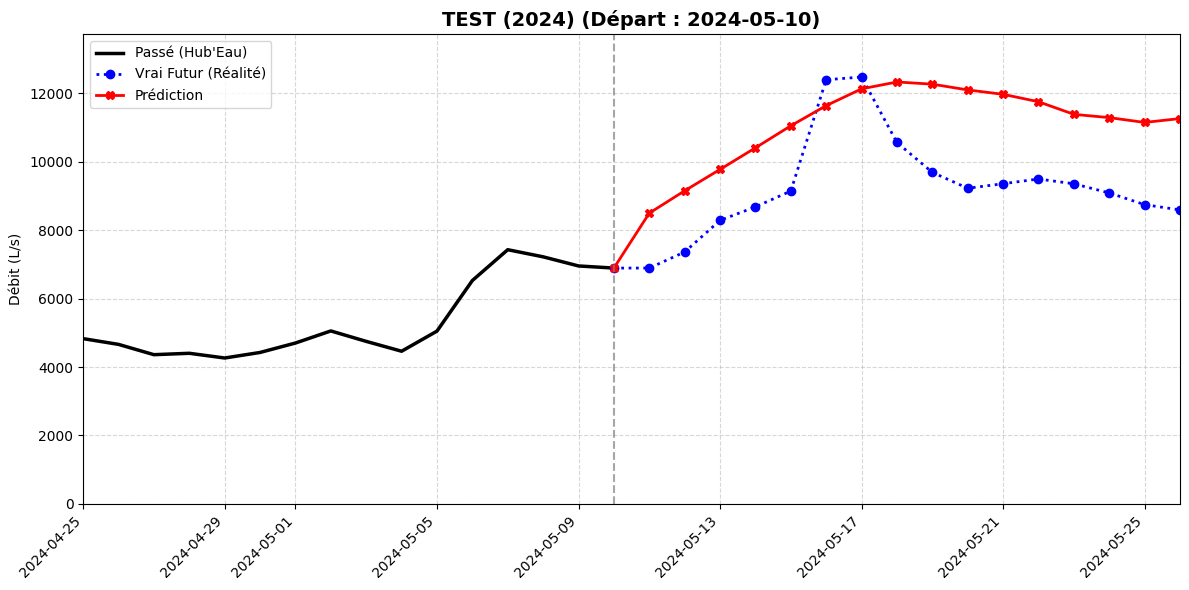

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


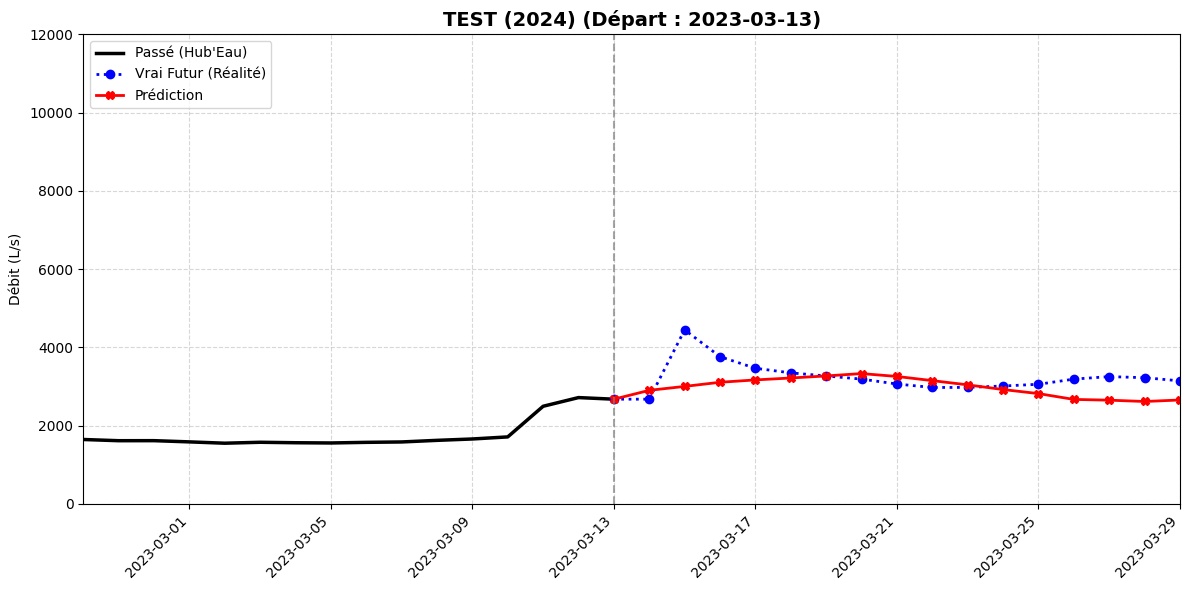

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


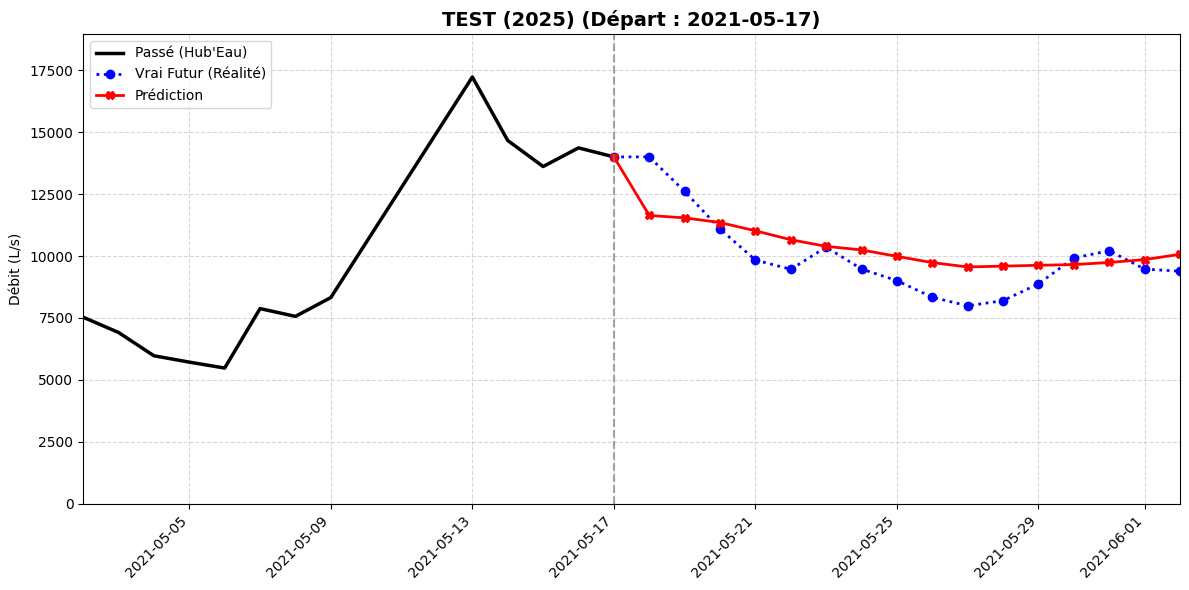

In [615]:
tracer_prediction(df, train, model_keras, features_X, "2019-05-10", "ENTRAÎNEMENT")
tracer_prediction(df, test, model_keras, features_X, "2024-05-10", "TEST (2024)")
tracer_prediction(df, test, model_keras, features_X, "2023-03-13", "TEST (2024)")
tracer_prediction(df, test, model_keras, features_X, "2021-05-17", "TEST (2025)")

([<matplotlib.axis.XTick at 0x136ef54c0>,
 [Text(0, 0, 'J+0'),
  Text(1, 0, 'J+1'),
  Text(2, 0, 'J+2'),
  Text(3, 0, 'J+3'),
  Text(4, 0, 'J+4'),
  Text(5, 0, 'J+5'),
  Text(6, 0, 'J+6'),
  Text(7, 0, 'J+7'),
  Text(8, 0, 'J+8'),
  Text(9, 0, 'J+9'),
  Text(10, 0, 'J+10'),
  Text(11, 0, 'J+11'),
  Text(12, 0, 'J+12'),
  Text(13, 0, 'J+13'),
  Text(14, 0, 'J+14'),
  Text(15, 0, 'J+15')])

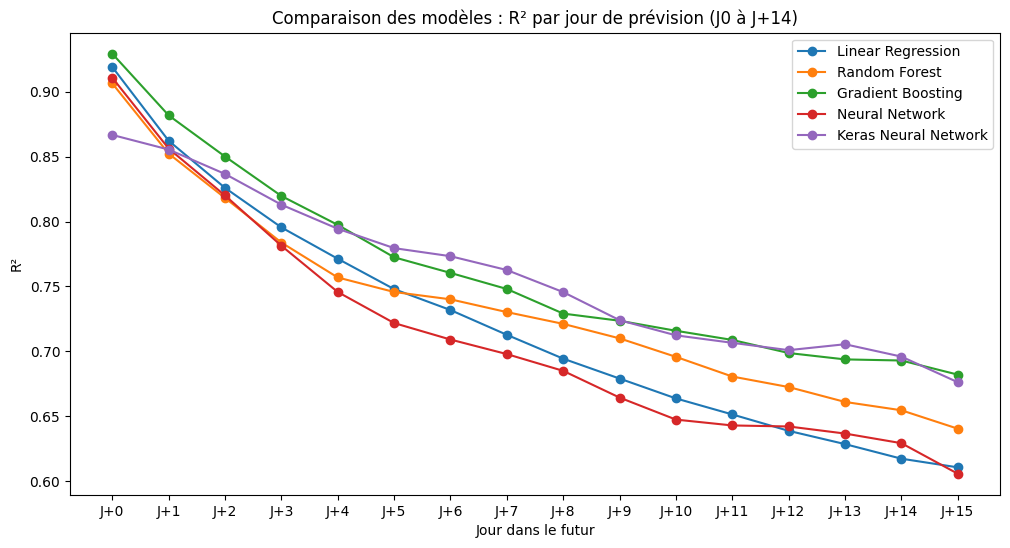

In [606]:
#graph score R2 des modèles
model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network', 'Keras Neural Network']
scores = [scores_r2_lin, scores_r2_rf, scores_r2_gb, scores_r2_nn, scores_r2_keras]
plt.figure(figsize=(12, 6))
for i, score in enumerate(scores):
    plt.plot(range(predict_day+1), score, marker='o', label=model_names[i])
plt.title("Comparaison des modèles : R² par jour de prévision (J0 à J+14)")
plt.xlabel("Jour dans le futur")
plt.ylabel("R²")
plt.legend()
plt.xticks(range(predict_day+1), [f"J+{i}" for i in range(predict_day+1)])

## Chercher le bassin versant de la rivière

On va chercher les points les plus corrélés avec le niveau d'eau de la rivière (ce qui revient à chercher le bassin versant de la rivière).

In [780]:


def obtenir_et_afficher_bassin(lat, lon):
    delta = 0.05 # On élargit un poil (5 km) pour être sûr de bien attraper le polygone
    bbox = f"{lon-delta},{lat-delta},{lon+delta},{lat+delta}"

    url = "https://services.sandre.eaufrance.fr/geo/sandre"
    params = {
        "SERVICE": "WFS",
        "VERSION": "1.0.0",         # La version 1.0.0 lit [Lon, Lat]
        "REQUEST": "GetFeature",
        "typeName": "ZoneHydro_FXX",
        "outputFormat": "geojson",  # Notre correctif qui marche
        "srsName": "EPSG:4326",
        "bbox": bbox
    }

    print("🌍 Interrogation de l'API Sandre...")
    try:
        rep = requests.get(url, params=params, timeout=10)
    except Exception as e:
        print(f"❌ Impossible de joindre l'API : {e}")
        return None

    if rep.status_code != 200:
        print(f"❌ Erreur Serveur (Code {rep.status_code})")
        return None

    try:
        geojson_data = rep.json()
    except:
        print("❌ L'API n'a pas renvoyé de JSON valide.")
        return None
    
    if 'features' not in geojson_data or len(geojson_data['features']) == 0:
        print("⚠️ Aucun bassin versant trouvé à ces coordonnées exactes.")
        # Pour t'aider à déboguer si ça rate :
        print(f"Lien de la requête brute : {rep.url}") 
        return None

    print(f"✅ Bassin versant trouvé ! (ID: {geojson_data['features'][0]['properties'].get('CdSecteurHydro', 'Inconnu')})")

    # Création de la carte
    carte = folium.Map(location=[lat, lon], zoom_start=11)

    # Ajout du tracé
    folium.GeoJson(
        geojson_data,
        name="Secteur Hydrographique",
        style_function=lambda feature: {
            'fillColor': '#1f77b4',   
            'color': '#0d47a1',       
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(carte)

    # Marqueur
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="red", icon="info-sign"),
        popup="📍 Station"
    ).add_to(carte)

    return carte


# ==========================================
STATION_LAT = 44.9003
STATION_LON = 5.9444
carte_bassin = obtenir_et_afficher_bassin(STATION_LAT, STATION_LON)

# Affichage de la carte dans le notebook
carte_bassin.save("bassin_versan.html")

🌍 Interrogation de l'API Sandre...
✅ Bassin versant trouvé ! (ID: W2)


In [782]:
# On crée des variables globales pour ne lire le disque dur qu'une seule fois
DF_EAU_OFFLINE = None
DF_METEO_OFFLINE = None

def evaluer_configuration_opti_offline(coords_list, split_date="2019-12-31", past_day_opti=20, predict_day_opti=15):
    """
    Évalue une configuration à partir des données pré-téléchargées (CSVs).
    Vitesse fulgurante garantie.
    """
    global DF_EAU_OFFLINE, DF_METEO_OFFLINE
    
    # ==========================================
    # 1. CHARGEMENT EN MÉMOIRE (Une seule fois)
    # ==========================================
    if DF_EAU_OFFLINE is None:
        print("Chargement des CSV en mémoire RAM...")
        DF_EAU_OFFLINE = pd.read_csv("cache_eau_offline.csv", parse_dates=['date'])
        DF_METEO_OFFLINE = pd.read_csv("cache_meteo_offline.csv", parse_dates=['date'])
        
    df_eau_opti = DF_EAU_OFFLINE.copy()
    df_meteo_complet = DF_METEO_OFFLINE.copy()

    # ==========================================
    # 2. FILTRAGE DES POINTS ET MOYENNE
    # ==========================================
    # On récupère uniquement les lignes qui correspondent aux coordonnées choisies par Optuna
    masque = pd.Series(False, index=df_meteo_complet.index)
    for lat, lon in coords_list:
        # On arrondit pour éviter les bugs de virgule flottante
        masque = masque | ((df_meteo_complet['lat'].round(4) == round(lat, 4)) & 
                           (df_meteo_complet['lon'].round(4) == round(lon, 4)))
        
    df_meteo_filtre = df_meteo_complet[masque].copy()
    
    # On supprime les colonnes lat/lon et on fait la moyenne spatiale par jour
    df_meteo_opti = df_meteo_filtre.drop(columns=['lat', 'lon']).groupby('date').mean().reset_index()

    # ==========================================
    # 3. FUSION ET DÉTECTION DES VARIABLES
    # ==========================================
    df_opti = pd.merge(df_eau_opti, df_meteo_opti, on='date', how='inner')
    df_opti = df_opti.sort_values('date').reset_index(drop=True)

    colonnes_meteo_opti = [col for col in df_meteo_opti.columns if col != 'date']

    # ==========================================
    # 4. CONSTRUCTION DES ENTRÉES (X) ET SORTIES (Y)
    # ==========================================
    features_X_opti = []
    targets_Y_opti = []
    dict_nouvelles_colonnes = {}

    # Historique rivière
    for i in range(1, past_day_opti + 1):
        nom_col = f"debit_J-{i}"
        dict_nouvelles_colonnes[nom_col] = df_opti['debit_L_s'].shift(i)
        features_X_opti.append(nom_col)

    # Météo passée
    for i in range(1, past_day_opti + 1):
        for var in colonnes_meteo_opti:
            nom_col = f"{var}_J-{i}"
            dict_nouvelles_colonnes[nom_col] = df_opti[var].shift(i)
            features_X_opti.append(nom_col)

    # Météo future et actuelle
    for i in range(0, predict_day_opti + 1):
        for var in colonnes_meteo_opti:
            nom_col = f"{var}_J+{i}"
            dict_nouvelles_colonnes[nom_col] = df_opti[var].shift(-i)
            features_X_opti.append(nom_col)

    # Date cyclique
    dict_nouvelles_colonnes['sin_date'] = np.sin(2 * np.pi * df_opti['date'].dt.dayofyear / 365.25)
    dict_nouvelles_colonnes['cos_date'] = np.cos(2 * np.pi * df_opti['date'].dt.dayofyear / 365.25)
    features_X_opti.extend(['sin_date', 'cos_date'])

    # Sortie Y
    for i in range(0, predict_day_opti + 1):
        nom_col = f"cible_debit_J+{i}"
        dict_nouvelles_colonnes[nom_col] = df_opti['debit_L_s'].shift(-i)
        targets_Y_opti.append(nom_col)

    df_opti = pd.concat([df_opti, pd.DataFrame(dict_nouvelles_colonnes)], axis=1)
    df_opti = df_opti.dropna()
    
    if len(df_opti) == 0:
        return None, -9999 # Score pourri si aucune donnée ne survit

    # ==========================================
    # 5. SÉPARATION TRAIN / TEST
    # ==========================================
    train_opti = df_opti[df_opti['date'] <= split_date]
    test_opti  = df_opti[df_opti['date'] > split_date]
    
    if len(train_opti) == 0 or len(test_opti) == 0:
        return None, -9999

    X_train_opti, Y_train_opti = train_opti[features_X_opti], train_opti[targets_Y_opti]
    X_test_opti,  Y_test_opti  = test_opti[features_X_opti],  test_opti[targets_Y_opti]

    # ==========================================
    # 6. ENTRAÎNEMENT & ÉVALUATION
    # ==========================================
    model_lin_opti = LinearRegression()
    model_lin_opti.fit(X_train_opti, Y_train_opti)

    predictions_opti = model_lin_opti.predict(X_test_opti)
    scores_r2_lin_opti_simple = r2_score(Y_test_opti, predictions_opti)
    
    # On renvoie tout dans une seule structure proprement
    return (model_lin_opti, scores_r2_lin_opti_simple)

In [852]:
from shapely.geometry import shape, Point

# ==========================================
# 1. PARAMÈTRES DE BASE
# ==========================================
STATION_LAT = 44.9003
STATION_LON = 5.9444
delta = 0.05 # Rayon de recherche autour de la station
bbox = f"{STATION_LON-delta},{STATION_LAT-delta},{STATION_LON+delta},{STATION_LAT+delta}"

# ==========================================
# 2. RÉCUPÉRATION DES ZONES VIA L'API SANDRE
# ==========================================
print("🌍 Récupération des bassins versants depuis l'API Sandre...")
url = "https://services.sandre.eaufrance.fr/geo/sandre"
params = {
    "SERVICE": "WFS",
    "VERSION": "1.0.0",
    "REQUEST": "GetFeature",
    "typeName": "ZoneHydro_FXX",
    "outputFormat": "geojson",
    "bbox": bbox
}

rep = requests.get(url, params=params)
if rep.status_code != 200:
    raise Exception(f"Erreur API Sandre (Code {rep.status_code})")

geojson_data = rep.json()
zones = geojson_data.get('features', [])
print(f"✅ {len(zones)} zones hydrographiques trouvées !")

# ==========================================
# 3. GÉNÉRATION DES POINTS AVEC SHAPELY
# ==========================================
points_par_zone = {}
print("\n🎯 Génération des points strictement à l'intérieur des zones...")

for i, feature in enumerate(zones):
    # Nom de la zone (ou Zone_X si inconnu)
    nom_zone = feature['properties'].get('LbZoneHydro', f"Zone_{i}")
    
    # Conversion du polygone GeoJSON en objet géométrique Shapely
    poly = shape(feature['geometry'])
    
    # On récupère les limites extrêmes de CETTE zone précise
    min_lon, min_lat, max_lon, max_lat = poly.bounds
    
    # Génération d'une grille de test
    lats = np.linspace(min_lat, max_lat, 15)
    lons = np.linspace(min_lon, max_lon, 15)
    
    points_valides = []
    
    # Test de chaque point
    for lat in lats:
        for lon in lons:
            point_gps = Point(lon, lat) # Shapely attend (Longitude, Latitude)
            if poly.contains(point_gps):
                points_valides.append((round(lat, 4), round(lon, 4)))
                
    # On limite à 25 points maximum, bien répartis
    if len(points_valides) > 25:
        indices = np.linspace(0, len(points_valides)-1, 25, dtype=int)
        points_valides = [points_valides[idx] for idx in indices]
        
    points_par_zone[nom_zone] = points_valides
    print(f"   -> {nom_zone} : {len(points_valides)} points validés.")

# Création d'une liste unique de tous les points pour le futur téléchargement météo
tous_les_points = [pt for sous_liste in points_par_zone.values() for pt in sous_liste]

# ==========================================
# 4. VISUALISATION SUR LA CARTE
# ==========================================
print("\n🗺️ Génération de la carte de vérification...")
carte = folium.Map(location=[STATION_LAT, STATION_LON], zoom_start=11)

# A. Affichage des polygones verts (Zones)
folium.GeoJson(
    geojson_data,
    style_function=lambda x: {'fillColor': '#2ca02c', 'color': '#006400', 'weight': 2, 'fillOpacity': 0.2},
    tooltip=folium.GeoJsonTooltip(fields=['LbZoneHydro'], aliases=['Zone:'])
).add_to(carte)

# B. Affichage des points générés (Une couleur différente par zone)
couleurs = ['blue', 'purple', 'orange', 'darkred', 'cadetblue', 'black']
for idx, (nom_zone, points) in enumerate(points_par_zone.items()):
    coul = couleurs[idx % len(couleurs)]
    for lat, lon in points:
        folium.CircleMarker(
            location=[lat, lon], 
            radius=4, 
            color=coul, 
            fill=True, 
            fill_color=coul, 
            fill_opacity=0.8,
            popup=nom_zone
        ).add_to(carte)

# C. Marqueur de ta station Hub'Eau
folium.Marker(
    [STATION_LAT, STATION_LON], 
    icon=folium.Icon(color="red", icon="info-sign"),
    popup="📍 Station Hub'Eau"
).add_to(carte)

# Affichage direct dans le Notebook
carte.save("point_bassin.html")

🌍 Récupération des bassins versants depuis l'API Sandre...
✅ 4 zones hydrographiques trouvées !

🎯 Génération des points strictement à l'intérieur des zones...
   -> La Malsanne : 25 points validés.
   -> La Bonne du canal de Beaumont inclus à la Malsanne : 25 points validés.
   -> La Bonne de la Malsanne au Drac : 25 points validés.
   -> Le Drac de la Souloise à la Bonne : 25 points validés.

🗺️ Génération de la carte de vérification...


In [789]:
def preparer_et_sauvegarder_donnees_offline(grille_coords, params_hourly, params_daily,
                                            STATION_opti="W231401001",
                                            START_FETCH_opti="2009-11-01",
                                            END_FETCH_opti="2017-02-01",
                                            fichier_eau="cache_eau_offline.csv",
                                            fichier_meteo="cache_meteo_offline.csv"):
    """
    Télécharge TOUTES les données de la grille une seule fois proprement 
    et les sauvegarde sur le disque dur pour une optimisation hors-ligne.
    """
    print(f"==========================================")
    print(f"🔄 ÉTAPE 1 : MOISSONNAGE DES DONNÉES")
    print(f"==========================================")
    
    # ----------------------------------------
    # 1. RIVIÈRE (Hub'Eau)
    # ----------------------------------------
    print(f"💧 Téléchargement Hub'Eau ({START_FETCH_opti} à {END_FETCH_opti})...")
    df_eau = fetch_river_data(STATION_opti, START_FETCH_opti, END_FETCH_opti)
    df_eau.to_csv(fichier_eau, index=False)
    print(f"✅ Sauvegardé -> {fichier_eau}")

    # ----------------------------------------
    # 2. MÉTÉO (Grille Open-Meteo)
    # ----------------------------------------
    print(f"\n🌤 Téléchargement Météo pour {len(grille_coords)} points...")
    print("⏳ (Une pause de 3s entre chaque point est appliquée pour éviter l'erreur 429)")
    
    list_df_meteo = []
    
    for i, (lat, lon) in enumerate(grille_coords):
        print(f"   -> [{i+1}/{len(grille_coords)}] Point ({lat}, {lon})...", end="")
        
        try:
            # On utilise ta fonction qui renvoie 2 tableaux
            df_h, df_d = fetch_weather_data(lat, lon, START_FETCH_opti, END_FETCH_opti, 
                                            daily_vars=params_daily, hourly_vars=params_hourly)
            
            # On convertit l'horaire en journalier étendu (ton ancienne fonction)
            if not df_h.empty:
                df_h_wide = hourly_to_wide_daily(df_h)
                df_pt = pd.merge(df_d, df_h_wide, on='date', how='outer')
            else:
                df_pt = df_d.copy()
            
            # === LE SECRET EST ICI ===
            # On ajoute les colonnes lat et lon pour identifier d'où viennent les données
            df_pt['lat'] = lat
            df_pt['lon'] = lon
            
            list_df_meteo.append(df_pt)
            print(" OK")
            
            # Pause de sécurité pour l'API (3 seconde)
            time.sleep(3)
            
        except Exception as e:
            print(f" ❌ ERREUR: {e}")
            # Petite pause supplémentaire si l'API commence à bloquer
            time.sleep(5)
            
    # ----------------------------------------
    # 3. FUSION ET SAUVEGARDE MÉTÉO
    # ----------------------------------------
    print("\n💾 Assemblage et sauvegarde de la base de données météo géante...")
    df_meteo_total = pd.concat(list_df_meteo, ignore_index=True)
    df_meteo_total.to_csv(fichier_meteo, index=False)
    
    print(f"✅ Sauvegardé -> {fichier_meteo}")
    print(f"🎯 Prêt pour Optuna ! (Taille de la base : {len(df_meteo_total)} lignes)")


In [790]:
# On rassemble tous les points de nos zones dans une seule liste
tous_les_points = []
for points in points_par_zone.values():
    tous_les_points.extend(points)

print(f"📥 Lancement du téléchargement pour les {len(tous_les_points)} points stratégiques...")

# On réutilise la fonction de moissonnage (assure-toi qu'elle est bien définie dans ton notebook)
preparer_et_sauvegarder_donnees_offline(
    grille_coords=tous_les_points,
    params_hourly=["snow_depth", "temperature_2m"], # Tes variables
    params_daily=["rain_sum"],
    STATION_opti="W231401001",
    START_FETCH_opti="2016-01-01", 
    END_FETCH_opti="2020-12-31",
    fichier_eau="cache_eau_offline.csv",
    fichier_meteo="cache_meteo_offline.csv"
)

📥 Lancement du téléchargement pour les 100 points stratégiques...
🔄 ÉTAPE 1 : MOISSONNAGE DES DONNÉES
💧 Téléchargement Hub'Eau (2016-01-01 à 2020-12-31)...
✅ Sauvegardé -> cache_eau_offline.csv

🌤 Téléchargement Météo pour 100 points...
⏳ (Une pause de 3s entre chaque point est appliquée pour éviter l'erreur 429)
   -> [1/100] Point (44.9107, 5.9431)... OK
   -> [2/100] Point (44.9107, 5.9886)... OK
   -> [3/100] Point (44.9188, 5.9613)... OK
   -> [4/100] Point (44.9188, 6.0069)... OK
   -> [5/100] Point (44.9269, 5.9704)... OK
   -> [6/100] Point (44.9269, 6.016)... OK
   -> [7/100] Point (44.9351, 5.9704)... OK
   -> [8/100] Point (44.9351, 6.016)... OK
   -> [9/100] Point (44.9432, 5.9522)... OK
   -> [10/100] Point (44.9432, 5.9977)... OK
   -> [11/100] Point (44.9513, 5.934)... OK
   -> [12/100] Point (44.9513, 5.9795)... OK
   -> [13/100] Point (44.9513, 6.0342)... OK
   -> [14/100] Point (44.9594, 5.9704)... OK
   -> [15/100] Point (44.9594, 6.016)... OK
   -> [16/100] Point (4

In [807]:
# Variables globales optimisées
DF_EAU_PRECALCULE = None
DICT_METEO_OFFLINE = None

def evaluer_configuration_opti_offline(coords_list, split_date="2019-12-31", past_day_opti=20, predict_day_opti=15):
    global DF_EAU_PRECALCULE, DICT_METEO_OFFLINE
    
    # ==========================================
    # 1. INITIALISATION UNIQUE (Le gros calcul est fait ici une seule fois)
    # ==========================================
    if DF_EAU_PRECALCULE is None:
        print("🚀 Premier lancement : Mise en cache et pré-calculs ultra-rapides...")
        df_eau = pd.read_csv("cache_eau_offline.csv", parse_dates=['date']).sort_values('date').reset_index(drop=True)
        df_meteo = pd.read_csv("cache_meteo_offline.csv", parse_dates=['date'])
        
        # A. Pré-calcul de TOUT l'historique de la rivière (Ça ne changera jamais)
        dict_eau_shifts = {}
        for i in range(1, past_day_opti + 1):
            dict_eau_shifts[f"debit_J-{i}"] = df_eau['debit_L_s'].shift(i)
        for i in range(0, predict_day_opti + 1):
            dict_eau_shifts[f"cible_debit_J+{i}"] = df_eau['debit_L_s'].shift(-i)
            
        dict_eau_shifts['sin_date'] = np.sin(2 * np.pi * df_eau['date'].dt.dayofyear / 365.25)
        dict_eau_shifts['cos_date'] = np.cos(2 * np.pi * df_eau['date'].dt.dayofyear / 365.25)
        
        DF_EAU_PRECALCULE = pd.concat([df_eau, pd.DataFrame(dict_eau_shifts)], axis=1)
        
        # B. Transformation de la météo en Dictionnaire pour accès instantané
        df_meteo['lat'] = df_meteo['lat'].round(4)
        df_meteo['lon'] = df_meteo['lon'].round(4)
        DICT_METEO_OFFLINE = {}
        
        for (lat, lon), group in df_meteo.groupby(['lat', 'lon']):
            # On stocke le dataframe indexé par date, propre, pour chaque point
            DICT_METEO_OFFLINE[(lat, lon)] = group.sort_values('date').set_index('date').drop(columns=['lat', 'lon'])
            
        print("✅ Pré-calcul terminé ! Optuna va maintenant voler.")

    # ==========================================
    # 2. RÉCUPÉRATION INSTANTANÉE ET MOYENNE
    # ==========================================
    dfs_a_moyenner = []
    for lat, lon in coords_list:
        coords = (round(lat, 4), round(lon, 4))
        if coords in DICT_METEO_OFFLINE:
            dfs_a_moyenner.append(DICT_METEO_OFFLINE[coords])
            
    if not dfs_a_moyenner:
        return None, -9999

    # Moyenne spatiale ultra-rapide
    df_meteo_mean = sum(dfs_a_moyenner) / len(dfs_a_moyenner)
    colonnes_meteo_opti = df_meteo_mean.columns

    # ==========================================
    # 3. DÉCALAGES MÉTÉO (Shifts)
    # ==========================================
    dict_m_shifts = {}
    
    # On shift tout le dataframe d'un coup (beaucoup plus rapide)
    for i in range(1, past_day_opti + 1):
        shifted = df_meteo_mean.shift(i)
        for col in colonnes_meteo_opti:
            dict_m_shifts[f"{col}_J-{i}"] = shifted[col]
            
    for i in range(0, predict_day_opti + 1):
        shifted = df_meteo_mean.shift(-i)
        for col in colonnes_meteo_opti:
            dict_m_shifts[f"{col}_J+{i}"] = shifted[col]
            
    df_meteo_opti = pd.DataFrame(dict_m_shifts, index=df_meteo_mean.index)

    # ==========================================
    # 4. FUSION ET SÉPARATION
    # ==========================================
    # Fusion via l'index de date
    df_opti = DF_EAU_PRECALCULE.merge(df_meteo_opti, left_on='date', right_index=True, how='inner').dropna()

    if len(df_opti) == 0:
        return None, -9999

    train_opti = df_opti[df_opti['date'] <= split_date]
    test_opti  = df_opti[df_opti['date'] > split_date]
    
    if len(train_opti) == 0 or len(test_opti) == 0:
        return None, -9999

    # ==========================================
    # 5. LISTE DES VARIABLES ET ENTRAÎNEMENT
    # ==========================================
    features_X_opti = [f"debit_J-{i}" for i in range(1, past_day_opti + 1)] + ['sin_date', 'cos_date']
    for i in range(1, past_day_opti + 1):
        features_X_opti.extend([f"{col}_J-{i}" for col in colonnes_meteo_opti])
    for i in range(0, predict_day_opti + 1):
        features_X_opti.extend([f"{col}_J+{i}" for col in colonnes_meteo_opti])

    targets_Y_opti = [f"cible_debit_J+{i}" for i in range(0, predict_day_opti + 1)]

    # Sécurité au cas où des colonnes manqueraient
    features_X_opti = [col for col in features_X_opti if col in train_opti.columns]

    X_train_opti, Y_train_opti = train_opti[features_X_opti], train_opti[targets_Y_opti]
    X_test_opti,  Y_test_opti  = test_opti[features_X_opti],  test_opti[targets_Y_opti]

    model_lin_opti = LinearRegression()
    model_lin_opti.fit(X_train_opti, Y_train_opti)

    predictions_opti = model_lin_opti.predict(X_test_opti)
    scores_r2_lin_opti_simple = r2_score(Y_test_opti, predictions_opti)
    
    return (model_lin_opti, scores_r2_lin_opti_simple)

In [809]:
import optuna
from tqdm import std

noms_zones = list(points_par_zone.keys())
listes_de_points = list(points_par_zone.values())

def objective(trial):
    coords_testees = []
    
    # 1. Optuna choisit exactement UN point dans CHAQUE zone
    for i in range(len(listes_de_points)):
        # CORRECTION : On utilise simplement l'index i pour garantir un nom unique (ex: "zone_0")
        idx = trial.suggest_int(f"zone_{i}", 0, len(listes_de_points[i]) - 1)
        coords_testees.append(listes_de_points[i][idx])
        
    # 2. On évalue la combinaison
    resultats = evaluer_configuration_opti_offline(
        coords_list=coords_testees,
        split_date="2019-12-31", 
        past_day_opti=20,
        predict_day_opti=15
    )
    
    if resultats[0] is None:
        return -9999
        
    return resultats[1]

# ==========================================
# LANCEMENT AVEC BARRE DE PROGRESSION
# ==========================================
optuna.logging.set_verbosity(optuna.logging.WARNING)
n_trials_total = 5000 

print(f"🚀 Lancement d'Optuna ({n_trials_total} essais)...")
pbar = std.tqdm(total=n_trials_total, desc="Recherche des points optimaux", unit="essai")

def tqdm_callback(study, trial):
    pbar.update(1)
    if study.best_value is not None:
        pbar.set_postfix({"Meilleur R²": f"{study.best_value * 100:.2f}%"})

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials_total, callbacks=[tqdm_callback])
pbar.close()

# ==========================================
# RÉSULTATS CORRIGÉS
# ==========================================
print("\n🏆 OPTIMISATION TERMINÉE !")
print(f"Meilleur score R² : {study.best_value * 100:.2f} %")

print("\n🌍 LES 4 POINTS GAGNANTS SONT :")
meilleurs_coords = []

# CORRECTION : On boucle sur nos 4 zones de départ pour être sûr de toutes les afficher
for i in range(len(listes_de_points)):
    # On récupère l'index gagnant via le nom sûr "zone_0", "zone_1", etc.
    idx_gagnant = study.best_params[f"zone_{i}"] 
    coord_gagnante = listes_de_points[i][idx_gagnant]
    meilleurs_coords.append(coord_gagnante)
    
    print(f" - {noms_zones[i]} : {coord_gagnante}")

🚀 Lancement d'Optuna (5000 essais)...


Recherche des points optimaux: 100%|██████████| 5000/5000 [46:30<00:00,  1.79essai/s, Meilleur R²=22.15%]    


🏆 OPTIMISATION TERMINÉE !
Meilleur score R² : 22.15 %

🌍 LES 4 POINTS GAGNANTS SONT :
 - La Malsanne : (np.float64(44.9188), np.float64(5.9613))
 - La Bonne du canal de Beaumont inclus à la Malsanne : (np.float64(44.9107), np.float64(6.0246))
 - La Bonne de la Malsanne au Drac : (np.float64(44.9089), np.float64(5.896))
 - Le Drac de la Souloise à la Bonne : (np.float64(44.7959), np.float64(5.8715))


In [849]:
import math
import random
import numpy as np
from deap import base, creator, tools
from tqdm import tqdm

# ==========================================
# 1. CRÉATION DES GRAPHES D'ADJACENCE
# ==========================================
def construire_matrice_adjacence(points, k=4):
    graphe = {}
    n = len(points)
    for i in range(n):
        distances = []
        for j in range(n):
            if i != j:
                dist = math.sqrt((points[i][0] - points[j][0])**2 + (points[i][1] - points[j][1])**2)
                distances.append((j, dist))
        distances.sort(key=lambda x: x[1])
        graphe[i] = [idx for idx, d in distances[:k]]
    return graphe

print("🕸️ Construction des matrices d'adjacence pour les 4 zones...")
graphes_par_zone = [construire_matrice_adjacence(zone, k=4) for zone in listes_de_points]

# ==========================================
# 2. CONFIGURATION DU MOTEUR DEAP
# ==========================================
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

def init_individu():
    return [random.randint(0, len(zone) - 1) for zone in listes_de_points]

toolbox.register("individu", tools.initIterate, creator.Individual, init_individu)
toolbox.register("population", tools.initRepeat, list, toolbox.individu)

# ==========================================
# 3. RÈGLES DE L'ÉVOLUTION SUR LE GRAPHE
# ==========================================
def evaluation(individu):
    coords = [listes_de_points[i][idx] for i, idx in enumerate(individu)]
    _, score = evaluer_configuration_opti_offline(
        coords_list=coords,
        split_date="2019-12-31", 
        past_day_opti=20, 
        predict_day_opti=15
    )
    # On renvoie le vrai R² (même s'il est négatif)
    return (score if score is not None else -9999,)

def mutation_sur_graphe(individu):
    zone_mut = random.randrange(len(individu))
    noeud_actuel = individu[zone_mut]
    voisins_possibles = graphes_par_zone[zone_mut][noeud_actuel]
    if voisins_possibles:
        individu[zone_mut] = random.choice(voisins_possibles)
    return individu,

toolbox.register("evaluate", evaluation)
toolbox.register("mutate", mutation_sur_graphe)
toolbox.register("mate", tools.cxUniform, indpb=0.5) 

# ==========================================
# 4. LE TABLEAU DE BORD (PARAMÈTRES AVANCÉS)
# ==========================================
TAILLE_POPULATION = 20
NOMBRE_GENERATIONS = 50
PROBA_CROISEMENT = 0.6
PROBA_MUTATION = 0.3

# --- ⚙️ LES OPTIONS À ACTIVER/DÉSACTIVER ---
ACTIVER_HALL_OF_FAME = False
TUER_LES_MAUVAIS = False
POURCENTAGE_A_TUER = 0.2

# --- 🎯 CHOIX DE LA MÉTHODE DE SÉLECTION ---
# Options possibles : "tournoi", "roulette", "elitisme", "sus"
METHODE_SELECTION = "sus"

if METHODE_SELECTION == "tournoi":
    toolbox.register("select", tools.selTournament, tournsize=3)
elif METHODE_SELECTION == "elitisme":
    toolbox.register("select", tools.selBest)
elif METHODE_SELECTION == "roulette":
    toolbox.register("select", tools.selRoulette)
elif METHODE_SELECTION == "sus":
    toolbox.register("select", tools.selStochasticUniversalSampling)

# ==========================================
# 5. LA BOUCLE D'ÉVOLUTION
# ==========================================
print(f"🧬 Lancement de l'Algorithme (Sélection : {METHODE_SELECTION.upper()})...")

pop = toolbox.population(n=TAILLE_POPULATION)
hof = tools.HallOfFame(1)

fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

if ACTIVER_HALL_OF_FAME:
    hof.update(pop)

pbar = tqdm(total=NOMBRE_GENERATIONS, desc="Évolution en cours", unit="gén")

for g in range(NOMBRE_GENERATIONS):
    
    if TUER_LES_MAUVAIS:
        nb_survivants = int(len(pop) * (1 - POURCENTAGE_A_TUER))
        pool_reproduction = tools.selBest(pop, nb_survivants)
    else:
        pool_reproduction = pop
        
    # --- Bouclier Mathématique pour Roulette et SUS ---
    # Ces algos plantent si la fitness est < 0. On décale tout vers le haut temporairement.
    if METHODE_SELECTION in ["roulette", "sus"]:
        pire_score = min([ind.fitness.values[0] for ind in pool_reproduction])
        if pire_score < 0:
            # On ajoute un décalage juste pour que la proportion soit respectée et positive
            for ind in pool_reproduction:
                ind.fitness.values = (ind.fitness.values[0] + abs(pire_score) + 0.001,)
                
        offspring = toolbox.select(pool_reproduction, len(pop))
        
        # On remet les vrais scores pour ne pas fausser l'affichage
        if pire_score < 0:
            for ind in pool_reproduction:
                ind.fitness.values = (ind.fitness.values[0] - abs(pire_score) - 0.001,)
    else:
        offspring = toolbox.select(pool_reproduction, len(pop))

    offspring = list(map(toolbox.clone, offspring))
    
    # Croisement
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < PROBA_CROISEMENT:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
            
    # Mutation
    for mutant in offspring:
        if random.random() < PROBA_MUTATION:
            toolbox.mutate(mutant)
            del mutant.fitness.values
            
    # Évaluation
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
        
    # 5. Remplacement de la population
    pop[:] = offspring
    
    # 6. Mise à jour du Panthéon ET Réinjection du Champion (Le Vrai Élitisme)
    if ACTIVER_HALL_OF_FAME:
        hof.update(pop)
        
        # 👑 C'EST ÇA LA MAGIE : On trouve le pire enfant de la nouvelle génération...
        pire_enfant_index = pop.index(min(pop, key=lambda ind: ind.fitness.values[0]))
        # ... et on l'écrase en clonant le champion absolu historique !
        pop[pire_enfant_index] = toolbox.clone(hof[0])
        
        meilleur_actuel = hof[0]
    else:
        meilleur_actuel = tools.selBest(pop, k=1)[0]
        
    pbar.set_postfix({"Meilleur R²": f"{meilleur_actuel.fitness.values[0] * 100:.2f}%"})
    pbar.update(1)

pbar.close()

# ==========================================
# 6. RÉSULTATS FINAUX
# ==========================================
meilleur_individu = hof[0] if ACTIVER_HALL_OF_FAME else tools.selBest(pop, k=1)[0]
meilleur_score = meilleur_individu.fitness.values[0]

print("\n==========================================")
print("🏆 OPTIMISATION GLOBALE TERMINÉE !")
print(f"Meilleur score R² trouvé : {meilleur_score * 100:.2f} %")
print("==========================================\n")

print("🌍 LES 4 POINTS STRATÉGIQUES GAGNANTS SONT :")
noms_zones = list(points_par_zone.keys())
for i, idx_gagnant in enumerate(meilleur_individu):
    coord_gagnante = listes_de_points[i][idx_gagnant]
    print(f" - {noms_zones[i]} : {coord_gagnante}")

🕸️ Construction des matrices d'adjacence pour les 4 zones...
🧬 Lancement de l'Algorithme (Sélection : SUS)...


Évolution en cours: 100%|██████████| 50/50 [04:43<00:00,  5.67s/gén, Meilleur R²=28.09%]


🏆 OPTIMISATION GLOBALE TERMINÉE !
Meilleur score R² trouvé : 28.09 %

🌍 LES 4 POINTS STRATÉGIQUES GAGNANTS SONT :
 - La Malsanne : (np.float64(44.9432), np.float64(5.9977))
 - La Bonne du canal de Beaumont inclus à la Malsanne : (np.float64(44.8992), np.float64(6.0505))
 - La Bonne de la Malsanne au Drac : (np.float64(44.922), np.float64(5.8623))
 - Le Drac de la Souloise à la Bonne : (np.float64(44.7959), np.float64(5.8715))


In [859]:
import math
import random
import numpy as np
from deap import base, creator, tools
from tqdm import tqdm

# ==========================================
# 1. CRÉATION DES GRAPHES D'ADJACENCE
# ==========================================
def construire_matrice_adjacence(points, k=4):
    graphe = {}
    n = len(points)
    for i in range(n):
        distances = []
        for j in range(n):
            if i != j:
                dist = math.sqrt((points[i][0] - points[j][0])**2 + (points[i][1] - points[j][1])**2)
                distances.append((j, dist))
        distances.sort(key=lambda x: x[1])
        graphe[i] = [idx for idx, d in distances[:k]]
    return graphe

print("🕸️ Construction des matrices d'adjacence pour les zones...")
graphes_par_zone = [construire_matrice_adjacence(zone, k=4) for zone in listes_de_points]
noms_zones = list(points_par_zone.keys())

# ==========================================
# 2. CONFIGURATION DU MOTEUR DEAP (TAILLE VARIABLE)
# ==========================================
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
# L'ADN est maintenant une liste de tuples : (ID_Zone, Index_Point)
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

def init_individu():
    # Au départ, on place 1 capteur par zone
    return [(i, random.randint(0, len(zone) - 1)) for i, zone in enumerate(listes_de_points)]

toolbox.register("individu", tools.initIterate, creator.Individual, init_individu)
toolbox.register("population", tools.initRepeat, list, toolbox.individu)

# ==========================================
# 3. RÈGLES DE L'ÉVOLUTION SUR LE GRAPHE ET MALFORMATIONS
# ==========================================
def evaluation(individu):
    # Reconstitution élastique des coordonnées
    coords = [listes_de_points[zone_id][pt_idx] for zone_id, pt_idx in individu]
    
    _, score = evaluer_configuration_opti_offline(
        coords_list=coords,
        split_date="2019-12-31", 
        past_day_opti=20, 
        predict_day_opti=15
    )
    return (score if score is not None else -9999,)

def mutation_variable(individu):
    """ Gère le déplacement, la duplication et la délétion """
    choix = random.random()
    
    # 60% : Déplacement sur le graphe
    if choix < 0.60 and len(individu) > 0:
        gene_idx = random.randrange(len(individu))
        zone_id, pt_idx = individu[gene_idx]
        voisins = graphes_par_zone[zone_id][pt_idx]
        if voisins:
            individu[gene_idx] = (zone_id, random.choice(voisins))
            
    # 20% : Ajout d'un nouveau capteur (Duplication)
    elif choix < 0.80:
        zone_id = random.randrange(len(listes_de_points))
        pt_idx = random.randint(0, len(listes_de_points[zone_id]) - 1)
        individu.append((zone_id, pt_idx))
        
    # 20% : Perte d'un capteur (Délétion) - Sécurité 1 point min.
    elif len(individu) > 1:
        gene_idx = random.randrange(len(individu))
        individu.pop(gene_idx)
        
    return individu,

toolbox.register("evaluate", evaluation)
toolbox.register("mutate", mutation_variable)
# Obligatoire pour les ADN de tailles variables : cxTwoPoint
toolbox.register("mate", tools.cxTwoPoint) 

# ==========================================
# 4. LE TABLEAU DE BORD (PARAMÈTRES AVANCÉS)
# ==========================================
TAILLE_POPULATION = 20
NOMBRE_GENERATIONS = 50
PROBA_CROISEMENT = 0.6
PROBA_MUTATION = 0.6 # Légèrement monté pour encourager les malformations

# --- ⚙️ LES OPTIONS À ACTIVER/DÉSACTIVER ---
ACTIVER_HALL_OF_FAME = True
TUER_LES_MAUVAIS = False
POURCENTAGE_A_TUER = 0.2

# --- 🎯 CHOIX DE LA MÉTHODE DE SÉLECTION ---
METHODE_SELECTION = "sus"

if METHODE_SELECTION == "tournoi":
    toolbox.register("select", tools.selTournament, tournsize=3)
elif METHODE_SELECTION == "elitisme":
    toolbox.register("select", tools.selBest)
elif METHODE_SELECTION == "roulette":
    toolbox.register("select", tools.selRoulette)
elif METHODE_SELECTION == "sus":
    toolbox.register("select", tools.selStochasticUniversalSampling)

# ==========================================
# 5. LA BOUCLE D'ÉVOLUTION
# ==========================================
print(f"🧬 Lancement de l'Algorithme (Sélection : {METHODE_SELECTION.upper()} | ADN Variable)...")

pop = toolbox.population(n=TAILLE_POPULATION)
hof = tools.HallOfFame(1)

fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

if ACTIVER_HALL_OF_FAME:
    hof.update(pop)

pbar = tqdm(total=NOMBRE_GENERATIONS, desc="Évolution en cours", unit="gén")

for g in range(NOMBRE_GENERATIONS):
    
    if TUER_LES_MAUVAIS:
        nb_survivants = int(len(pop) * (1 - POURCENTAGE_A_TUER))
        pool_reproduction = tools.selBest(pop, nb_survivants)
    else:
        pool_reproduction = pop
        
    # --- Bouclier Mathématique pour Roulette et SUS ---
    if METHODE_SELECTION in ["roulette", "sus"]:
        pire_score = min([ind.fitness.values[0] for ind in pool_reproduction])
        if pire_score < 0:
            for ind in pool_reproduction:
                ind.fitness.values = (ind.fitness.values[0] + abs(pire_score) + 0.001,)
                
        offspring = toolbox.select(pool_reproduction, len(pop))
        
        if pire_score < 0:
            for ind in pool_reproduction:
                ind.fitness.values = (ind.fitness.values[0] - abs(pire_score) - 0.001,)
    else:
        offspring = toolbox.select(pool_reproduction, len(pop))

    offspring = list(map(toolbox.clone, offspring))
    
    # Croisement
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < PROBA_CROISEMENT:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
            
    # Mutation Variable
    for mutant in offspring:
        if random.random() < PROBA_MUTATION:
            toolbox.mutate(mutant)
            del mutant.fitness.values
            
    # Évaluation
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
        
    # Remplacement
    pop[:] = offspring
    
    # Mise à jour du Panthéon ET Réinjection du Champion
    if ACTIVER_HALL_OF_FAME:
        hof.update(pop)
        pire_enfant_index = pop.index(min(pop, key=lambda ind: ind.fitness.values[0]))
        pop[pire_enfant_index] = toolbox.clone(hof[0])
        meilleur_actuel = hof[0]
    else:
        meilleur_actuel = tools.selBest(pop, k=1)[0]
        
    pbar.set_postfix({
        "Meilleur R²": f"{meilleur_actuel.fitness.values[0] * 100:.2f}%", 
        "Capteurs": len(meilleur_actuel)
    })
    pbar.update(1)

pbar.close()

# ==========================================
# 6. RÉSULTATS FINAUX
# ==========================================
meilleur_individu = hof[0] if ACTIVER_HALL_OF_FAME else tools.selBest(pop, k=1)[0]
meilleur_score = meilleur_individu.fitness.values[0]

print("\n==========================================")
print("🏆 OPTIMISATION GLOBALE TERMINÉE !")
print(f"Meilleur score R² trouvé : {meilleur_score * 100:.2f} %")
print(f"Nombre final de capteurs retenus : {len(meilleur_individu)}")
print("==========================================\n")

print("🌍 COORDONNÉES DES CAPTEURS SURVIVANTS :")
for zone_id, pt_idx in meilleur_individu:
    coord = listes_de_points[zone_id][pt_idx]
    print(f" - {noms_zones[zone_id]} : {coord}")

🕸️ Construction des matrices d'adjacence pour les zones...
🧬 Lancement de l'Algorithme (Sélection : SUS | ADN Variable)...


Évolution en cours: 100%|██████████| 50/50 [05:06<00:00,  6.13s/gén, Meilleur R²=26.31%, Capteurs=7]


🏆 OPTIMISATION GLOBALE TERMINÉE !
Meilleur score R² trouvé : 26.31 %
Nombre final de capteurs retenus : 7

🌍 COORDONNÉES DES CAPTEURS SURVIVANTS :
 - La Malsanne : (np.float64(44.9432), np.float64(5.9977))
 - La Bonne de la Malsanne au Drac : (np.float64(44.922), np.float64(5.9185))
 - La Bonne de la Malsanne au Drac : (np.float64(44.922), np.float64(5.9185))
 - Le Drac de la Souloise à la Bonne : (np.float64(44.7959), np.float64(5.8715))
 - La Bonne de la Malsanne au Drac : (np.float64(44.922), np.float64(5.8623))
 - Le Drac de la Souloise à la Bonne : (np.float64(44.7879), np.float64(5.8539))
 - Le Drac de la Souloise à la Bonne : (np.float64(44.8521), np.float64(5.8715))


In [ ]:
print("\n🗺️ Génération de la carte globale (Recherche + Vainqueurs)...")

# 1. On récupère les coordonnées finales
coords_gagnantes = [listes_de_points[i][idx] for i, idx in enumerate(meilleur_individu)]

# 2. Calcul du centre de la carte (moyenne géométrique des points)
lat_moyenne = sum([c[0] for c in coords_gagnantes]) / len(coords_gagnantes)
lon_moyenne = sum([c[1] for c in coords_gagnantes]) / len(coords_gagnantes)

# 3. Création de la carte avec un fond de plan clair
carte_optimisation = folium.Map(location=[lat_moyenne, lon_moyenne], zoom_start=10, tiles="CartoDB positron")

# 4. JUMELAGE : Affichage de TOUS les points explorables en fond (Petits cercles)
couleurs_zones = ['blue', 'green', 'purple', 'orange']
for i, zone in enumerate(listes_de_points):
    couleur = couleurs_zones[i % len(couleurs_zones)]
    for pt in zone:
        folium.CircleMarker(
            location=[pt[0], pt[1]],
            radius=3, # Petit point discret
            color=couleur,
            fill=True,
            fill_opacity=0.3,
            weight=1,
            tooltip=f"{noms_zones[i]} (Point explorable)"
        ).add_to(carte_optimisation)

# 5. Ajout des marqueurs pour les 4 points gagnants (Par-dessus le fond)
for i, coord in enumerate(coords_gagnantes):
    folium.Marker(
        location=[coord[0], coord[1]],
        popup=f"<b>{noms_zones[i]}</b><br>Lat: {coord[0]}<br>Lon: {coord[1]}",
        tooltip=f"🏆 Point Optimal - {noms_zones[i]}",
        icon=folium.Icon(color="red", icon="star")
    ).add_to(carte_optimisation)

# 6. Sauvegarde dans un fichier HTML
nom_fichier = "carte_optimisation_globale.html"
carte_optimisation.save(nom_fichier)

print(f"✅ Carte complète sauvegardée avec succès ! Ouvre '{nom_fichier}' pour admirer le travail.")


🗺️ Génération de la carte des résultats avec les zones...


TypeError: list indices must be integers or slices, not tuple

In [800]:
import pandas as pd
import math

# 1. On lit les coordonnées disponibles dans le fichier cache (sans toucher à l'API)
print("📂 Lecture des coordonnées disponibles dans le cache hors-ligne...")
df_cache = pd.read_csv("cache_meteo_offline.csv", usecols=['lat', 'lon'])
points_dispos = df_cache.drop_duplicates().values # Tableau de [lat, lon] uniques

# Les 4 barycentres que ton script a trouvés
barycentres_coords = [
    (44.9547, 5.9797), # La Malsanne
    (44.9008, 6.0262), # La Bonne du canal de Beaumont
    (44.9478, 5.8814), # La Bonne de la Malsanne au Drac
    (44.8374, 5.8876)  # Le Drac de la Souloise à la Bonne
]

noms_zones = [
    "La Malsanne",
    "La Bonne (canal)",
    "La Bonne (Malsanne-Drac)",
    "Le Drac (Souloise-Bonne)"
]

# Fonction pour calculer la distance (Euclidienne simple)
def distance_geo(lat1, lon1, lat2, lon2):
    return math.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

points_substituts = []

print("\n🔍 Recherche des points les plus proches dans le cache...")
for i, (lat_bary, lon_bary) in enumerate(barycentres_coords):
    meilleur_point = None
    distance_min = float('inf')
    
    # On teste tous les points de ton fichier CSV
    for lat_cache, lon_cache in points_dispos:
        dist = distance_geo(lat_bary, lon_bary, lat_cache, lon_cache)
        if dist < distance_min:
            distance_min = dist
            meilleur_point = (round(lat_cache, 4), round(lon_cache, 4))
            
    points_substituts.append(meilleur_point)
    print(f"   -> {noms_zones[i]} :")
    print(f"      Barycentre exact : ({lat_bary}, {lon_bary})")
    print(f"      Point substitut  : {meilleur_point} (Distance rel. : {distance_min:.4f})")

# ==========================================
# 2. ÉVALUATION DU SCORE DE RÉFÉRENCE (BASELINE)
# ==========================================
print("\n⚙️ Évaluation du modèle avec les points de substitution...")

# On charge les DataFrames complets en mémoire globale pour la fonction
global DF_EAU_OFFLINE, DF_METEO_OFFLINE
DF_EAU_OFFLINE = pd.read_csv("cache_eau_offline.csv", parse_dates=['date'])
DF_METEO_OFFLINE = pd.read_csv("cache_meteo_offline.csv", parse_dates=['date'])

resultats_bary = evaluer_configuration_opti_offline(
    coords_list=points_substituts,
    split_date="2019-12-31", 
    past_day_opti=20,
    predict_day_opti=15
)

if resultats_bary[0] is not None:
    print("\n==========================================")
    print(f"🏆 SCORE DE RÉFÉRENCE (BARYCENTRES PROCHES) : {resultats_bary[1] * 100:.2f} %")
    print("==========================================")
else:
    print("❌ Erreur lors de l'évaluation (pas assez de données ou NaN).")

📂 Lecture des coordonnées disponibles dans le cache hors-ligne...

🔍 Recherche des points les plus proches dans le cache...
   -> La Malsanne :
      Barycentre exact : (44.9547, 5.9797)
      Point substitut  : (np.float64(44.9513), np.float64(5.9795)) (Distance rel. : 0.0034)
   -> La Bonne (canal) :
      Barycentre exact : (44.9008, 6.0262)
      Point substitut  : (np.float64(44.905), np.float64(6.0246)) (Distance rel. : 0.0045)
   -> La Bonne (Malsanne-Drac) :
      Barycentre exact : (44.9478, 5.8814)
      Point substitut  : (np.float64(44.9481), np.float64(5.8623)) (Distance rel. : 0.0191)
   -> Le Drac (Souloise-Bonne) :
      Barycentre exact : (44.8374, 5.8876)
      Point substitut  : (np.float64(44.8521), np.float64(5.8715)) (Distance rel. : 0.0218)

⚙️ Évaluation du modèle avec les points de substitution...

🏆 SCORE DE RÉFÉRENCE (BARYCENTRES PROCHES) : 5.07 %


In [ ]:
def objective(trial):
    # Optuna pioche 1 index pour chaque zone séparément
    idx_z0 = trial.suggest_int("p_zone_1", 0, len(listes_de_points[0]) - 1)
    idx_z1 = trial.suggest_int("p_zone_2", 0, len(listes_de_points[1]) - 1)
    idx_z2 = trial.suggest_int("p_zone_3", 0, len(listes_de_points[2]) - 1)
    idx_z3 = trial.suggest_int("p_zone_4", 0, len(listes_de_points[3]) - 1)
    
    # On construit la combinaison des 4 points stratégiques
    coords_testees = [
        listes_de_points[0][idx_z0],
        listes_de_points[1][idx_z1],
        listes_de_points[2][idx_z2],
        listes_de_points[3][idx_z3]
    ]
    
    # Appel de ton modèle hors-ligne avec ces 4 points parfaits
    resultats = evaluer_configuration_opti_offline(
        coords_list=coords_testees,
        split_date="2019-12-31", 
        past_day_opti=20,
        predict_day_opti=15
    )
    
    # Gestion du crash si NaN
    if resultats[0] is None:
        return -9999
        
    return resultats[1] # On retourne le score R²

In [679]:
def fetch_weather_data_multi(coords_list, start_date, end_date, daily_vars, hourly_vars, max_retries=5):
    """
    Une seule requête HTTP pour tous les points de coords_list.
    Retourne une liste de tuples (df_hourly, df_daily), dans le même ordre que coords_list.
    """
    url = "https://archive-api.open-meteo.com/v1/archive" if datetime.strptime(end_date, "%Y-%m-%d") < datetime.now() else "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": [c[0] for c in coords_list],
        "longitude": [c[1] for c in coords_list],
        "daily": daily_vars,
        "hourly": hourly_vars,
        "start_date": start_date,
        "end_date": end_date,
    }

    for attempt in range(max_retries):
        resp = requests.get(url, params=params)
        if resp.status_code == 200:
            break
        elif resp.status_code == 429:
            wait = 2 ** attempt  # 1, 2, 4, 8, 16 s
            print(f"429 reçu, retry dans {wait}s (tentative {attempt+1}/{max_retries})...")
            time.sleep(wait)
        else:
            raise Exception(f"Erreur Open-Meteo : {resp.status_code}")
    else:
        raise Exception("Échec après plusieurs tentatives (429 persistant)")

    data = resp.json()

    # Avec plusieurs coordonnées, l'API renvoie une LISTE d'objets (un par point)
    # au lieu d'un seul dict comme en mono-point
    if isinstance(data, dict):
        data = [data]

    resultats = []
    for point_data in data:
        df_daily = pd.DataFrame()
        if 'daily' in point_data:
            df_daily = pd.DataFrame(point_data['daily'])
            df_daily['date'] = pd.to_datetime(df_daily['time'])
            df_daily.drop(columns=['time'], inplace=True)

        df_hourly = pd.DataFrame()
        if 'hourly' in point_data:
            df_hourly = pd.DataFrame(point_data['hourly'])
            df_hourly['date'] = pd.to_datetime(df_hourly['time'])
            df_hourly.drop(columns=['time'], inplace=True)

        resultats.append((df_hourly, df_daily))

    return resultats

In [739]:
# ==========================================
# MÉMOIRE CACHE GLOBALE (Pour accélérer l'optimisation)
# ==========================================
CACHE_EAU_OPTI = None
CACHE_METEO_OPTI = {}

In [ ]:
def generer_grille_autour_station(lat_station, lon_station, rayon_km=25, nb_points_par_cote=10):
    """
    Génère un quadrillage parfait de coordonnées autour d'un point central.
    Par défaut : un carré de 50x50 km contenant 100 points (10x10).
    """
    # 1 degré de latitude = ~111 km partout sur Terre
    delta_lat = rayon_km / 111.0
    
    # 1 degré de longitude = ~111 km * cos(latitude)
    delta_lon = rayon_km / (111.0 * np.cos(np.radians(lat_station)))
    
    # Génération des axes (de -rayon à +rayon)
    lats = np.linspace(lat_station - delta_lat, lat_station + delta_lat, nb_points_par_cote)
    lons = np.linspace(lon_station - delta_lon, lon_station + delta_lon, nb_points_par_cote)
    
    # Création de la liste des coordonnées
    grille_coords = []
    for lat in lats:
        for lon in lons:
            grille_coords.append((round(lat, 4), round(lon, 4)))
            
    print(f"🌍 Quadrillage généré : {len(grille_coords)} points dans un rayon de {rayon_km} km.")
    return grille_coords

# Exemple d'utilisation 100% autonome
lat_center, lon_center = 44.9003, 5.9444
ma_grille = generer_grille_autour_station(lat_center, lon_center)

🌍 Quadrillage généré : 100 points dans un rayon de 25 km.


In [753]:
ma_grille2 = generer_grille_autour_station(lat_center, lon_center, rayon_km=40, nb_points_par_cote=100)

🌍 Quadrillage généré : 10000 points dans un rayon de 40 km.


In [754]:
ma_grille2[2]

(np.float64(44.5399), np.float64(5.4562))

In [756]:
# ==========================================
# EXÉCUTION DU CODE (À lancer UNE SEULE FOIS)
# ==========================================
ma_grille = generer_grille_autour_station(lat_center, lon_center)
mes_params_hourly = ["snow_depth", "temperature_2m"] 
mes_params_daily  = ["rain_sum"]

# On réutilise la grille générée précédemment
preparer_et_sauvegarder_donnees_offline(
    grille_coords=ma_grille,
    params_hourly=mes_params_hourly,
    params_daily=mes_params_daily,
    STATION_opti="W231401001",
    START_FETCH_opti="2016-01-01",  # Période réduite pour l'optimisation
    END_FETCH_opti="2020-12-31"
)

🌍 Quadrillage généré : 100 points dans un rayon de 25 km.
🔄 ÉTAPE 1 : MOISSONNAGE DES DONNÉES
💧 Téléchargement Hub'Eau (2016-01-01 à 2020-12-31)...
✅ Sauvegardé -> cache_eau_offline.csv

🌤 Téléchargement Météo pour 100 points...
⏳ (Une pause de 1.5s entre chaque point est appliquée pour éviter l'erreur 429)
   -> [1/100] Point (44.6751, 5.6264)... OK
   -> [2/100] Point (44.6751, 5.6971)... OK
   -> [3/100] Point (44.6751, 5.7678)... OK
   -> [4/100] Point (44.6751, 5.8384)... OK
   -> [5/100] Point (44.6751, 5.9091)... OK
   -> [6/100] Point (44.6751, 5.9797)... OK
   -> [7/100] Point (44.6751, 6.0504)... OK
   -> [8/100] Point (44.6751, 6.121)... OK
   -> [9/100] Point (44.6751, 6.1917)... OK
   -> [10/100] Point (44.6751, 6.2624)... OK
   -> [11/100] Point (44.7251, 5.6264)... OK
   -> [12/100] Point (44.7251, 5.6971)... OK
   -> [13/100] Point (44.7251, 5.7678)... OK
   -> [14/100] Point (44.7251, 5.8384)... OK
   -> [15/100] Point (44.7251, 5.9091)... OK
   -> [16/100] Point (44.7

In [759]:
import folium

def visualiser_points_sur_carte(liste_coords, lat_station=None, lon_station=None):
    """
    Génère une carte interactive OpenStreetMap avec les points de la grille.
    """
    if not liste_coords:
        print("Erreur : La liste de coordonnées est vide.")
        return None

    # 1. Calcul du centre de la carte pour bien placer la caméra
    lats = [coord[0] for coord in liste_coords]
    lons = [coord[1] for coord in liste_coords]
    centre_lat = sum(lats) / len(lats)
    centre_lon = sum(lons) / len(lons)

    # 2. Création de la carte de base
    carte = folium.Map(location=[centre_lat, centre_lon], zoom_start=10)

    # 3. Ajout des 100 points de la grille (en petits cercles bleus)
    for lat, lon in liste_coords:
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,               # Taille du point
            color="#1f77b4",        # Couleur de la bordure
            fill=True,
            fill_color="#1f77b4",   # Couleur de remplissage
            fill_opacity=0.7,
            popup=f"Lat: {lat}<br>Lon: {lon}" # Info bulle au clic
        ).add_to(carte)

    # 4. (Optionnel) Ajout d'un gros marqueur rouge pour ta station de référence
    if lat_station and lon_station:
        folium.Marker(
            location=[lat_station, lon_station],
            icon=folium.Icon(color="red", icon="info-sign"),
            popup="STATION HUB'EAU"
        ).add_to(carte)

    return carte

In [763]:
# Affichage de la carte (assure-toi d'avoir exécuté la génération de ma_grille avant)
carte_grille = visualiser_points_sur_carte(ma_grille, lat_station=44.9139, lon_station=6.1285)

carte_grille

In [802]:
# Un point pour tester
mes_coordonnees = [(44.876274, 6.132501), (44.98719151985236, 5.967171650249039), (44.961795344025845, 6.006465614472453), (44.91875932255258, 6.137778488469194)]
# Les paramètres à tester
mes_params_hourly = ["snow_depth", "temperature_2m", ] #"vapour_pressure_deficit" pas déconnant
mes_params_daily  = ["rain_sum"] #, "et0_fao_evapotranspiration" pas déconnant

# Appel de la fonction
modele_retourne, scores_r2, X_train2, Y_train2, X_test2,  Y_test2, features_X2, targets_Y2 = evaluer_configuration_opti(
    coords_list=mes_coordonnees, 
    params_hourly=mes_params_hourly,
    params_daily=mes_params_daily,
    STATION_opti="W231401001",
    START_FETCH_opti="2000-11-01",
    END_FETCH_opti="2026-02-01",
    split_date="2020-12-31",
    past_day_opti=20,
    predict_day_opti=15
)
print(f"Score R² pour cette configuration : {scores_r2 * 100:.2f} %")

Lignes avant dropna : 9175
Lignes après dropna : 9052
Lignes dans l'entraînement (Train) : 7314
Lignes dans le test (Test) : 1738

--- RÉSULTATS RÉGRESSION LINÉAIRE (Test) ---
Prévision J0 (Aujourd'hui) : R² =  80.3 %
Prévision J+1             : R² =  62.5 %
Prévision J+2             : R² =  54.1 %
Prévision J+3             : R² =  48.9 %
Prévision J+4             : R² =  48.3 %
Prévision J+5             : R² =  48.9 %
Prévision J+6             : R² =  50.3 %
Prévision J+7             : R² =  52.3 %
Prévision J+8             : R² =  51.4 %
Prévision J+9             : R² =  47.0 %
Prévision J+10            : R² =  42.1 %
Prévision J+11            : R² =  40.0 %
Prévision J+12            : R² =  38.9 %
Prévision J+13            : R² =  36.7 %
Prévision J+14            : R² =  35.2 %
Prévision J+15            : R² =  33.6 %
Score R² pour cette configuration : 48.16 %


In [ ]:
# Instanciation et entraînement
model_rf2 = RandomForestRegressor(random_state=42, n_jobs=-1)
model_rf2.fit(X_train2, Y_train2)

# Prédiction sur l'année de test
predictions_rf2 = model_rf2.predict(X_test2)

# Évaluation jour par jour
scores_r2_rf2 = r2_score(Y_test2, predictions_rf2, multioutput='raw_values')
scores_r2_rf2_simple = r2_score(Y_test2, predictions_rf2)

print("\n--- RÉSULTATS FORÊT ALÉATOIRE (Random Forest) ---")
for i, score in enumerate(scores_r2_rf2):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")
scores_r2_rf2_simple = r2_score(Y_test2, predictions_rf2)
print(f"Score R² pour cette configuration : {scores_r2_rf2_simple * 100:.2f} %")


--- RÉSULTATS FORÊT ALÉATOIRE (Random Forest) ---
Prévision J0 (Aujourd'hui) : R² =  85.4 %
Prévision J+1             : R² =  78.2 %
Prévision J+2             : R² =  73.7 %
Prévision J+3             : R² =  70.0 %
Prévision J+4             : R² =  66.2 %
Prévision J+5             : R² =  65.2 %
Prévision J+6             : R² =  62.5 %
Prévision J+7             : R² =  58.3 %
Prévision J+8             : R² =  58.9 %
Prévision J+9             : R² =  56.9 %
Prévision J+10            : R² =  54.8 %
Prévision J+11            : R² =  54.1 %
Prévision J+12            : R² =  51.8 %
Prévision J+13            : R² =  50.2 %
Prévision J+14            : R² =  48.8 %
Prévision J+15            : R² =  50.5 %
Score R² pour cette configuration : 61.59 %


In [713]:
# Instanciation du modèle de base, enveloppé pour supporter les 15 dimensions de Y
modele_de_base_gb2 = HistGradientBoostingRegressor(random_state=42)
model_gb2 = MultiOutputRegressor(modele_de_base_gb2)

# Entraînement
model_gb2.fit(X_train2, Y_train2)

# Prédiction sur l'année de test
predictions_gb2= model_gb2.predict(X_test2)

# Évaluation jour par jour
scores_r2_gb2 = r2_score(Y_test2, predictions_gb2, multioutput='raw_values')

print("\n--- RÉSULTATS GRADIENT BOOSTING ---")
for i, score in enumerate(scores_r2_gb2):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")
scores_r2_gb2_simple = r2_score(Y_test2, predictions_gb2)
print(f"Score R² pour cette configuration : {scores_r2_gb2_simple * 100:.2f} %")


--- RÉSULTATS GRADIENT BOOSTING ---
Prévision J0 (Aujourd'hui) : R² =  91.1 %
Prévision J+1             : R² =  86.3 %
Prévision J+2             : R² =  83.4 %
Prévision J+3             : R² =  81.3 %
Prévision J+4             : R² =  77.5 %
Prévision J+5             : R² =  75.2 %
Prévision J+6             : R² =  72.9 %
Prévision J+7             : R² =  71.3 %
Prévision J+8             : R² =  70.2 %
Prévision J+9             : R² =  68.6 %
Prévision J+10            : R² =  66.9 %
Prévision J+11            : R² =  67.0 %
Prévision J+12            : R² =  65.0 %
Prévision J+13            : R² =  64.2 %
Prévision J+14            : R² =  65.9 %
Prévision J+15            : R² =  66.1 %
Score R² pour cette configuration : 73.31 %


In [723]:
# Fixer la graine pour la reproductibilité
tf.random.set_seed(42)

# --- Conversion des DataFrames Pandas en matrices NumPy ---
X_train_np2 = X_train2[features_X2].values.astype(np.float32)
Y_train_np2 = Y_train2[targets_Y2].values.astype(np.float32)
X_test_np2 = X_test2[features_X2].values.astype(np.float32)
Y_test_np2 = Y_test2[targets_Y2].values.astype(np.float32)

# 1. Couche de normalisation intégrée
norm_layer2 = tf.keras.layers.Normalization(input_shape=(X_train_np2.shape[1],))

# 2. Construction du modèle — architecture avec régularisation
model_keras2 = tf.keras.Sequential([
    norm_layer2,
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),


    tf.keras.layers.Dense(predict_day + 1)
])

# 3. Compilation
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_keras2.compile(loss="huber", optimizer=optimizer)

# 4. Entraînement de la couche de normalisation sur les données brutes
norm_layer2.adapt(X_train_np2)

# 5. Callbacks : arrêt anticipé + réduction du learning rate si ça stagne
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6
)

# 6. Entraînement du réseau
print("Début de l'entraînement Keras...")
history2 = model_keras2.fit(
    X_train_np2, Y_train_np2,
    epochs=200,  # patience early_stop coupera avant si ça overfit
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 7. Évaluation
print("\nCalcul des prédictions sur le jeu de test...")
predictions_keras2 = model_keras2.predict(X_test_np2)

scores_r2_keras2 = r2_score(Y_test_np2, predictions_keras2, multioutput='raw_values')

print("\n--- RÉSULTATS TENSORFLOW / KERAS ---")
for i, score in enumerate(scores_r2_keras2):
    jour_label = "J0 (Aujourd'hui)" if i == 0 else f"J+{i}"
    print(f"Prévision {jour_label:<15} : R² = {score * 100:>5.1f} %")
scores_r2_keras2_simple = r2_score(Y_test2, predictions_keras2)
print(f"Score R² pour cette configuration : {scores_r2_keras2_simple * 100:.2f} %")

Début de l'entraînement Keras...
Epoch 1/200


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4343.8359 - val_loss: 3171.1604 - learning_rate: 0.0010
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2805.2351 - val_loss: 1763.4515 - learning_rate: 0.0010
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2224.5483 - val_loss: 1198.2085 - learning_rate: 0.0010
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1724.1270 - val_loss: 1126.0245 - learning_rate: 0.0010
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1459.8815 - val_loss: 1115.8441 - learning_rate: 0.0010
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1297.3770 - val_loss: 1157.6749 - learning_rate: 0.0010
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1207.4540 - val_loss: 1080.6642 - learning_rate: 0.0010
Epoch 8/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1167.1489 - val_loss: 1063.2375 - learning_rate: 0.0010
Epoch 9/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1138.9640 - val_loss: 1027.8331 -

In [771]:



def objective(trial):
    # On demande à Optuna de choisir 4 index différents dans notre grille de 100 points
    idx_p1 = trial.suggest_int("p1", 0, len(ma_grille) - 1)
    idx_p2 = trial.suggest_int("p2", 0, len(ma_grille) - 1)
    idx_p3 = trial.suggest_int("p3", 0, len(ma_grille) - 1)
    idx_p4 = trial.suggest_int("p4", 0, len(ma_grille) - 1)
    
    # On convertit les index en vraies coordonnées (lat, lon)
    coords_testees = [
        ma_grille[idx_p1],
        ma_grille[idx_p2],
        ma_grille[idx_p3],
        ma_grille[idx_p4]
    ]
    
    # On appelle l'évaluation HORS-LIGNE (0 appel API)
    resultats = evaluer_configuration_opti_offline(
        coords_list=coords_testees,
        split_date="2019-12-31", 
        past_day_opti=20,
        predict_day_opti=15
    )
    
    # Récupération du score R² (c'est le 2ème élément retourné par la fonction)
    score_r2 = resultats[1]
    
    return score_r2

# ==========================================
# LANCEMENT DE L'OPTIMISATION AVEC BARRE DE PROGRESSION
# ==========================================
optuna.logging.set_verbosity(optuna.logging.WARNING)

n_trials_total = 1000
print(f"🚀 Lancement d'Optuna ({n_trials_total} essais en cours)...")

# Utilisation de la version stricte "std" pour éviter le bug de rendu VS Code/tqdm
from tqdm import std
pbar = std.tqdm(total=n_trials_total, desc="Optimisation des points", unit="essai")

def tqdm_callback(study, trial):
    pbar.update(1)
    if study.best_value is not None:
        pbar.set_postfix({"Meilleur R²": f"{study.best_value * 100:.1f}%"})

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=n_trials_total, callbacks=[tqdm_callback])

# Fermeture sécurisée
pbar.close()

print("\n🏆 OPTIMISATION TERMINÉE !")
print(f"Meilleur score R² : {study.best_value * 100:.2f} %")
print("Meilleurs points (Index dans la grille) :")
print(study.best_params)

meilleurs_coords = [ma_grille[idx] for idx in study.best_params.values()]
print(f"\n🌍 Coordonnées optimales trouvées : {meilleurs_coords}")

🚀 Lancement d'Optuna (1000 essais en cours)...


Optimisation des points: 100%|██████████| 1000/1000 [06:28<00:00,  2.57essai/s, Meilleur R²=28.1%]


🏆 OPTIMISATION TERMINÉE !
Meilleur score R² : 28.14 %
Meilleurs points (Index dans la grille) :
{'p1': 97, 'p2': 74, 'p3': 1, 'p4': 79}

🌍 Coordonnées optimales trouvées : [(np.float64(45.1255), np.float64(6.121)), (np.float64(45.0254), np.float64(5.9091)), (np.float64(44.6751), np.float64(5.6971)), (np.float64(45.0254), np.float64(6.2624))]
